# Chapter 12: Linear Regression

**ISM4641 - Python for Business Analytics**  
**University of South Florida**  
**Spring 2026**

---

### Overview

Linear regression is the most widely used predictive model in business analytics. This week we move from *testing whether differences exist* (Week 11) to **predicting how much** — building mathematical models that turn data into actionable forecasts.

**What you will learn:**

1. How regression finds the "best" line through data — and why there's only one
2. How to read and interpret the regression equation (intercept, slope, residuals)
3. How to measure model quality with R² and RMSE
4. Why overfitting happens and how train-test split guards against it
5. How to build, evaluate, and interpret regression models with scikit-learn
6. How to use multiple features for better predictions
7. When to trust your model — and when not to

## Table of Contents

- [12.1 From Description to Prediction](#12.1-From-Description-to-Prediction)
- [12.2 Visual Intuition — Fitting a Line to Data](#12.2-Visual-Intuition-—-Fitting-a-Line-to-Data)
- [12.3 The Equation and How to Read It](#12.3-The-Equation-and-How-to-Read-It)
- [12.4 Measuring Model Quality — R² and RMSE](#12.4-Measuring-Model-Quality-—-R²-and-RMSE)
- [12.5 Transformations, Overfitting, and Train-Test Split](#12.5-Transformations,-Overfitting,-and-Train-Test-Split)
- [12.6 The scikit-learn Workflow](#12.6-The-scikit-learn-Workflow)
- [12.7 Multiple Regression — More Features, Better Predictions](#12.7-Multiple-Regression-—-More-Features,-Better-Predictions)
- [12.8 Assumptions and Residual Analysis](#12.8-Assumptions-and-Residual-Analysis)
- [12.9 Business Scenarios and Common Pitfalls](#12.9-Business-Scenarios-and-Common-Pitfalls)
- [Summary and Quick Reference](#Summary-and-Quick-Reference)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Course data repository
DATA_URL = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/main"

# Display settings
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## 12.1 From Description to Prediction

Last week you learned to test *whether* a difference exists (hypothesis testing). This week you learn to model *how much* one variable predicts another.

| Week 11 (Inferential) | Week 12 (Predictive) |
|------------------------|----------------------|
| "Is there a difference?" | "How much will it be?" |
| "Is the new ad better?" | "How much revenue will the ad generate?" |
| t-tests, p-values | Regression, R², predictions |
| Yes/No answer | A number you can act on |

**Regression finds the mathematical relationship between variables so you can predict outcomes.** It's the workhorse of predictive analytics — if you work with data in business, you will use regression.

### Key Terminology

- **Target (y):** What you want to predict (sales, price, revenue). Also called the *dependent variable*.
- **Features (X):** What you use to make the prediction (ad spend, square footage, years of experience). Also called *independent variables* or *predictors*.
- **Simple regression:** One feature predicts the target.
- **Multiple regression:** Several features predict the target together.

### Business Applications of Linear Regression

| Application | Target (y) | Features (X) | Business Question |
|:------------|:-----------|:-------------|:------------------|
| Sales Forecasting | Revenue | Ad spend, season | "How much will we sell next quarter?" |
| House Pricing | Price | Sqft, bedrooms, location | "What should we list this house at?" |
| Demand Planning | Units sold | Price, promotions, weather | "How many units should we stock?" |
| Cost Estimation | Project cost | Hours, team size, complexity | "What will this project cost?" |
| Salary Prediction | Salary | Experience, education, role | "What's a fair offer for this candidate?" |

**Every row is a regression model waiting to be built.** The question is always the same: *"Given what I know about the inputs, what's my best guess for the output?"*

---

## 12.2 Visual Intuition — Fitting a Line to Data

Before any math, let's build intuition. Imagine you're a marketing manager with data on advertising spend and resulting sales across 80 campaigns. You want to see if there's a pattern — and if you can use it to predict future sales.

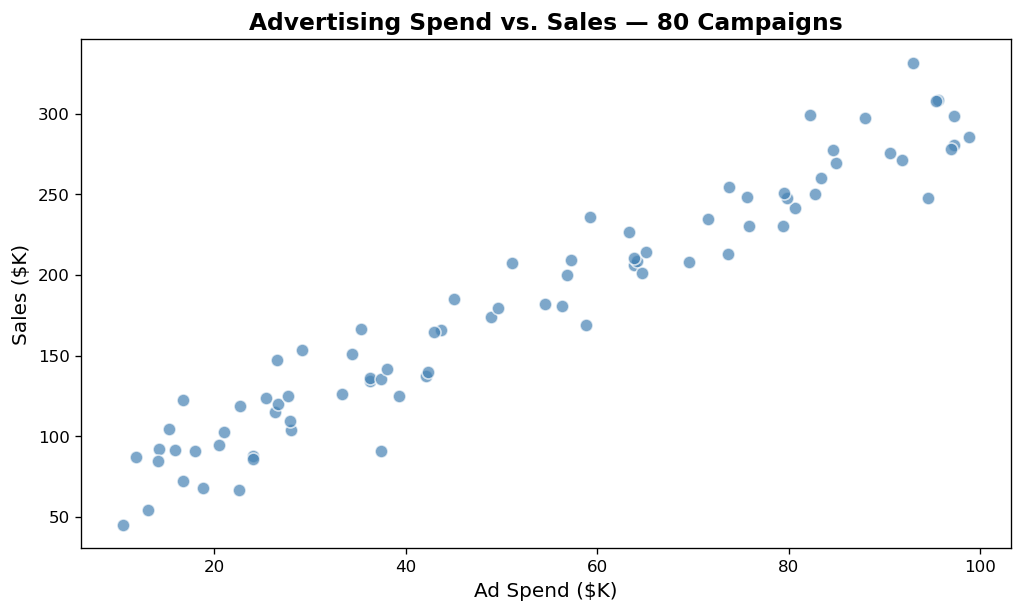

There's clearly a pattern — more ad spend tends to mean more sales.
But the relationship isn't perfect. Can we draw a line that captures the trend?


In [2]:
# Generate realistic advertising data
np.random.seed(42)
ad_spend = np.random.uniform(10, 100, 80)
sales = 50 + 2.5 * ad_spend + np.random.normal(0, 20, 80)

plt.figure(figsize=(10, 5.5))
plt.scatter(ad_spend, sales, color='steelblue', alpha=0.7, edgecolor='white', s=60)
plt.title('Advertising Spend vs. Sales — 80 Campaigns', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend ($K)', fontsize=12)
plt.ylabel('Sales ($K)', fontsize=12)
plt.show()

print("There's clearly a pattern — more ad spend tends to mean more sales.")
print("But the relationship isn't perfect. Can we draw a line that captures the trend?")

### Drawing the Best Line

Linear regression finds the **single straight line** that best fits all the data points. This line minimizes the total distance between every point and the line itself.

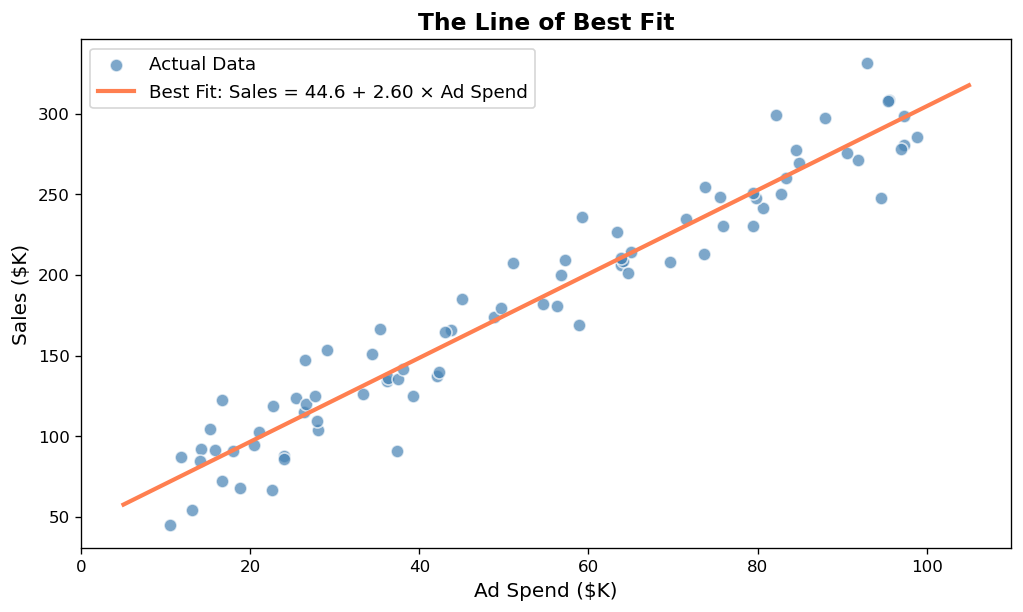

Equation: Sales = 44.6 + 2.60 × Ad_Spend

This means: for every $1K increase in ad spend, sales increase by about $2.60K


In [3]:
# Fit the regression line
np.random.seed(42)
ad_spend = np.random.uniform(10, 100, 80)
sales = 50 + 2.5 * ad_spend + np.random.normal(0, 20, 80)

X = ad_spend.reshape(-1, 1)
model = LinearRegression()
model.fit(X, sales)
line_x = np.linspace(5, 105, 100)
line_y = model.predict(line_x.reshape(-1, 1))

plt.figure(figsize=(10, 5.5))
plt.scatter(ad_spend, sales, color='steelblue', alpha=0.7, edgecolor='white', s=60, label='Actual Data')
plt.plot(line_x, line_y, color='coral', linewidth=2.5,
         label=f'Best Fit: Sales = {model.intercept_:.1f} + {model.coef_[0]:.2f} × Ad Spend')
plt.title('The Line of Best Fit', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend ($K)', fontsize=12)
plt.ylabel('Sales ($K)', fontsize=12)
plt.legend(fontsize=11)
plt.show()

print(f"Equation: Sales = {model.intercept_:.1f} + {model.coef_[0]:.2f} × Ad_Spend")
print(f"\nThis means: for every $1K increase in ad spend, sales increase by about ${model.coef_[0]:.2f}K")

### What Makes It "Best"? — Residuals

The "best" line minimizes the total **squared distance** from every point to the line. These vertical distances are called **residuals**:

$$\text{Residual}_i = y_i - \hat{y}_i = \text{Actual} - \text{Predicted}$$

- A **positive residual** means the model underpredicted (actual was higher).
- A **negative residual** means the model overpredicted (actual was lower).
- The "best" line minimizes $\sum (\text{residuals})^2$ — the **sum of squared residuals**.

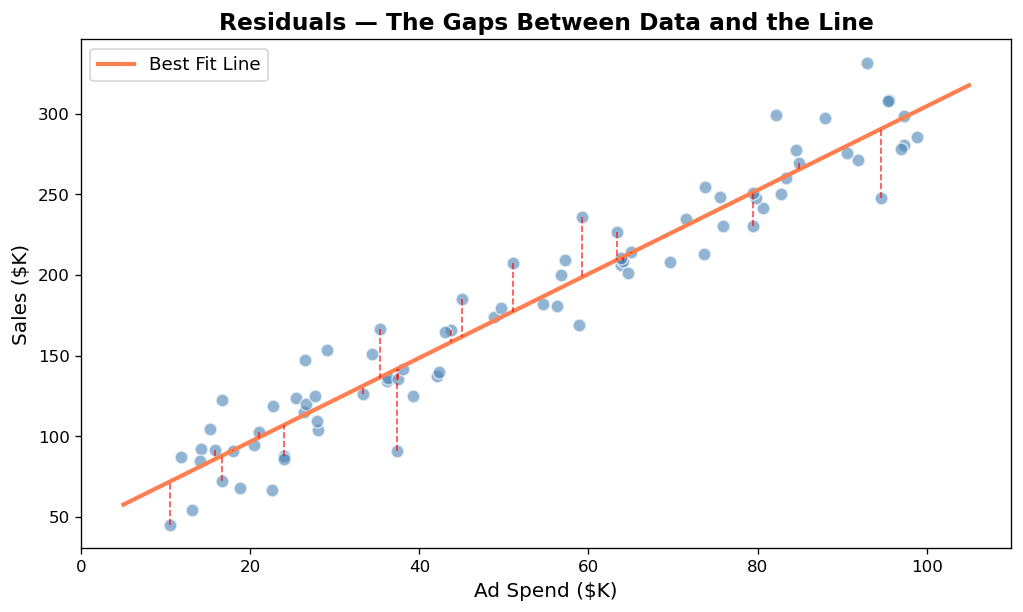

Sum of residuals:         -0.0000  (always ≈ 0)
Sum of squared residuals: 28756.2  (this is what OLS minimizes)


In [4]:
# Visualize residuals — the gaps between data and the line
np.random.seed(42)
ad_spend = np.random.uniform(10, 100, 80)
sales = 50 + 2.5 * ad_spend + np.random.normal(0, 20, 80)

X = ad_spend.reshape(-1, 1)
model = LinearRegression()
model.fit(X, sales)
predicted = model.predict(X)

plt.figure(figsize=(10, 5.5))
plt.scatter(ad_spend, sales, color='steelblue', alpha=0.6, edgecolor='white', s=60)

line_x = np.linspace(5, 105, 100)
line_y = model.predict(line_x.reshape(-1, 1))
plt.plot(line_x, line_y, color='coral', linewidth=2.5, label='Best Fit Line')

# Draw residual lines for every 4th point
for i in range(0, len(ad_spend), 4):
    plt.plot([ad_spend[i], ad_spend[i]], [sales[i], predicted[i]],
             color='red', linewidth=1, alpha=0.7, linestyle='--')

plt.title('Residuals — The Gaps Between Data and the Line', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend ($K)', fontsize=12)
plt.ylabel('Sales ($K)', fontsize=12)
plt.legend(fontsize=11)
plt.show()

residuals = sales - predicted
print(f"Sum of residuals:         {np.sum(residuals):.4f}  (always ≈ 0)")
print(f"Sum of squared residuals: {np.sum(residuals**2):.1f}  (this is what OLS minimizes)")

### Why Is There Only One "Best" Line?

For every possible combination of intercept (β₀) and slope (β₁), we can calculate the total error (MSE). If we plot *all* of these, we get a **bowl-shaped surface** — and the single lowest point on the bowl is the best line.

This is called **Ordinary Least Squares (OLS)**: it finds the one combination of intercept and slope that sits at the very bottom of the error bowl. There's no guessing — the math guarantees a unique answer.

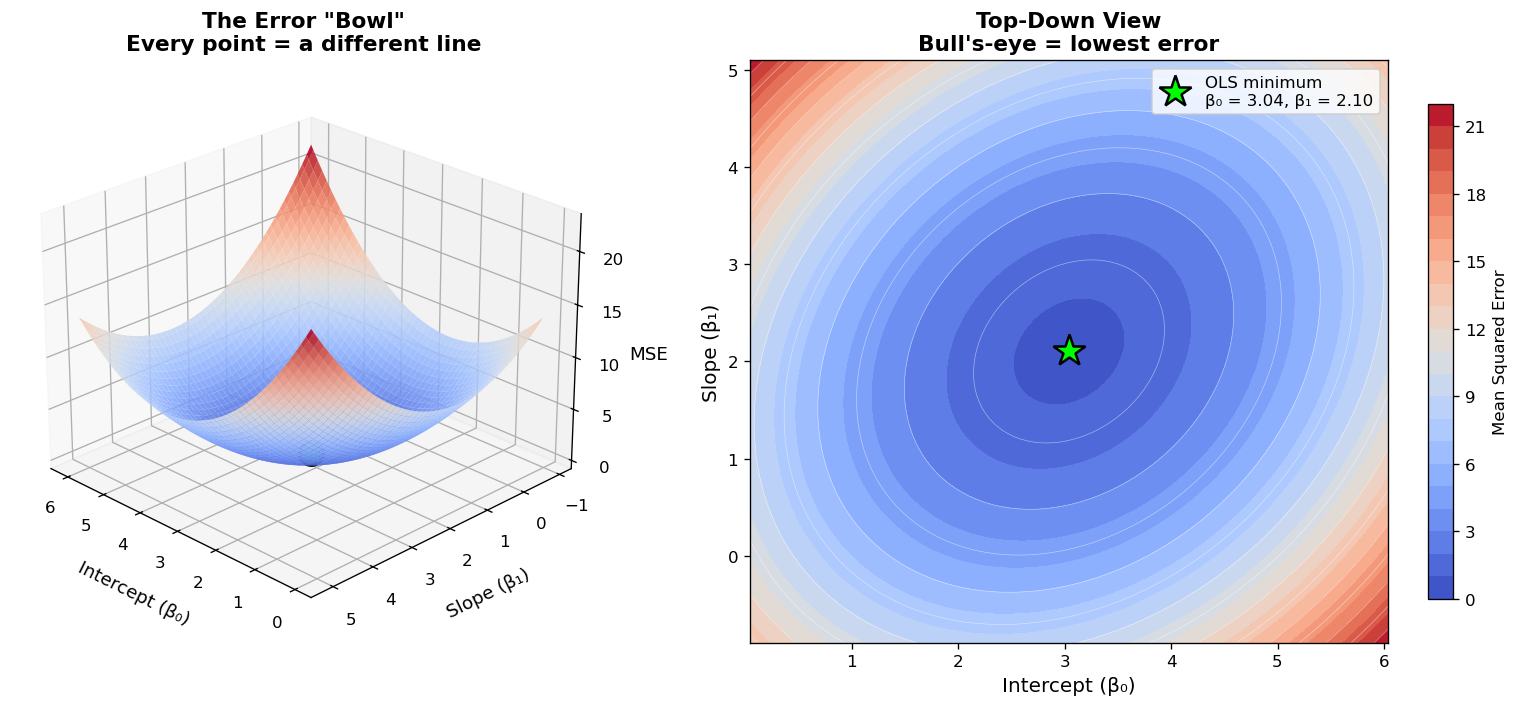

OLS solution: β₀ = 3.04, β₁ = 2.10, MSE = 0.7401
There's exactly ONE minimum — one best line. OLS finds it.


In [5]:
# The error landscape — a bowl with one minimum
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
x = np.random.normal(0, 1, 50)
y = 3 + 2 * x + np.random.normal(0, 1, 50)

model = LinearRegression().fit(x.reshape(-1, 1), y)
b0_opt = model.intercept_
b1_opt = model.coef_[0]
mse_opt = np.mean((y - model.predict(x.reshape(-1, 1)))**2)

# Grid of possible intercept/slope values
b0_range = np.linspace(b0_opt - 3, b0_opt + 3, 100)
b1_range = np.linspace(b1_opt - 3, b1_opt + 3, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)

MSE = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        pred = B0[i, j] + B1[i, j] * x
        MSE[i, j] = np.mean((y - pred)**2)

fig = plt.figure(figsize=(14, 6))

# Left: 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(B0, B1, MSE, cmap='coolwarm', alpha=0.9, edgecolor='none', rstride=2, cstride=2)
ax1.scatter([b0_opt], [b1_opt], [mse_opt], color='lime', s=200, zorder=10,
            edgecolor='black', linewidth=2, depthshade=False)
ax1.set_xlabel('\nIntercept (β₀)', fontsize=11)
ax1.set_ylabel('\nSlope (β₁)', fontsize=11)
ax1.set_zlabel('\nMSE', fontsize=11)
ax1.set_title('The Error "Bowl"\nEvery point = a different line', fontsize=13, fontweight='bold')
ax1.view_init(elev=25, azim=135)

# Right: contour (top-down view)
ax2 = fig.add_subplot(122)
cp = ax2.contourf(B0, B1, MSE, levels=25, cmap='coolwarm')
ax2.contour(B0, B1, MSE, levels=15, colors='white', linewidths=0.4, alpha=0.5)
ax2.plot(b0_opt, b1_opt, '*', color='lime', markersize=20, markeredgecolor='black',
         markeredgewidth=1.5, zorder=10,
         label=f'OLS minimum\nβ₀ = {b0_opt:.2f}, β₁ = {b1_opt:.2f}')
ax2.set_xlabel('Intercept (β₀)', fontsize=12)
ax2.set_ylabel('Slope (β₁)', fontsize=12)
ax2.set_title("Top-Down View\nBull's-eye = lowest error", fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
plt.colorbar(cp, ax=ax2, label='Mean Squared Error', shrink=0.85)

plt.tight_layout()
plt.show()

print(f"OLS solution: β₀ = {b0_opt:.2f}, β₁ = {b1_opt:.2f}, MSE = {mse_opt:.4f}")
print("There's exactly ONE minimum — one best line. OLS finds it.")

---

## 12.3 The Equation and How to Read It

Every linear regression produces an equation you can read like a sentence:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

| Symbol | Name | What It Means |
|:-------|:-----|:--------------|
| $y$ | Target | The thing you're predicting |
| $\beta_0$ | Intercept | The **baseline** — predicted y when x = 0 |
| $\beta_1$ | Slope (Coefficient) | The **per-unit change** — how much y changes for each 1-unit increase in x |
| $x$ | Feature | The input you're using to predict |
| $\varepsilon$ | Error (residual) | The part the model can't explain (randomness) |

**The intercept is where the line crosses the y-axis. The slope is how steeply it climbs.**

### Interpreting the Equation — A Business Example

From our ad spend model: **Sales = 48.5K + 2.53K × Ad_Spend**

| Component | Value | Business Interpretation |
|:----------|:------|:------------------------|
| Intercept (β₀) | 48.5K | Baseline sales with zero ad spend |
| Slope (β₁) | 2.53K | Every additional $1K in ad spend → $2.53K more in sales |

**How to use it:**

- Spend $30K on ads → Predicted sales = 48.5K + 2.53K × 30 = **$124.4K**
- Spend $60K on ads → Predicted sales = 48.5K + 2.53K × 60 = **$200.3K**
- Spend $0 → Predicted sales = **$48.5K** (the intercept)

**The slope is the actionable number.** It tells you the return on each dollar of ad spend. This is the kind of insight that drives business decisions.

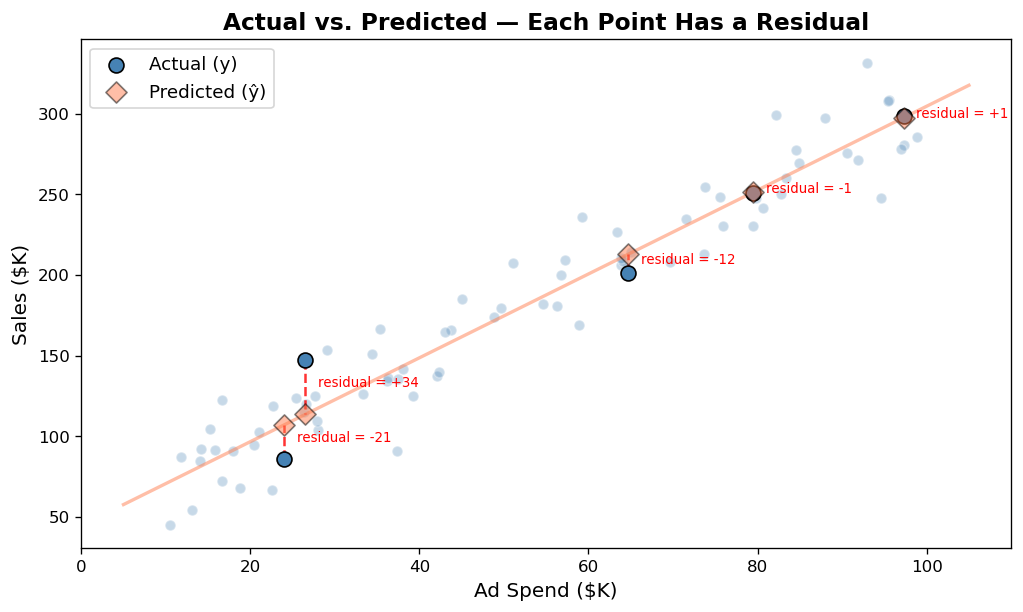

● Circle = actual value
◆ Diamond = predicted value (on the line)
-- Dashed line = residual (the error)

Positive residual = model underpredicted. Negative = overpredicted.


In [6]:
# Every point has a prediction and a residual
np.random.seed(42)
ad_spend = np.random.uniform(10, 100, 80)
sales = 50 + 2.5 * ad_spend + np.random.normal(0, 20, 80)

X = ad_spend.reshape(-1, 1)
model = LinearRegression()
model.fit(X, sales)
predicted = model.predict(X)

# Pick 5 representative points to annotate
idx = [5, 15, 30, 50, 70]
plt.figure(figsize=(10, 5.5))
line_x = np.linspace(5, 105, 100)
line_y = model.predict(line_x.reshape(-1, 1))
plt.plot(line_x, line_y, color='coral', linewidth=2, alpha=0.5)
plt.scatter(ad_spend, sales, color='steelblue', alpha=0.3, edgecolor='white', s=40)

for i in idx:
    plt.scatter(ad_spend[i], sales[i], color='steelblue', s=80, zorder=5, edgecolor='black')
    plt.scatter(ad_spend[i], predicted[i], color='coral', s=80, zorder=5,
                marker='D', edgecolor='black', alpha=0.5)
    plt.plot([ad_spend[i], ad_spend[i]], [sales[i], predicted[i]],
             color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    residual = sales[i] - predicted[i]
    plt.annotate(f'residual = {residual:+.0f}',
                 xy=(ad_spend[i] + 1.5, (sales[i] + predicted[i]) / 2),
                 fontsize=8, color='red')

plt.scatter([], [], color='steelblue', s=80, edgecolor='black', label='Actual (y)')
plt.scatter([], [], color='coral', s=80, marker='D', edgecolor='black', alpha=0.5, label='Predicted (ŷ)')
plt.title('Actual vs. Predicted — Each Point Has a Residual', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend ($K)', fontsize=12)
plt.ylabel('Sales ($K)', fontsize=12)
plt.legend(fontsize=11)
plt.show()

print("● Circle = actual value")
print("◆ Diamond = predicted value (on the line)")
print("-- Dashed line = residual (the error)")
print("\nPositive residual = model underpredicted. Negative = overpredicted.")

---

## 12.4 Measuring Model Quality — R² and RMSE

How do we know if our model is any good? Two key metrics tell the story:

- **R² (R-squared):** What fraction of the variation in y is explained by x? Ranges from 0 (useless) to 1 (perfect).
- **RMSE (Root Mean Squared Error):** How far off are our predictions, on average, in the original units?

Let's build intuition for both.

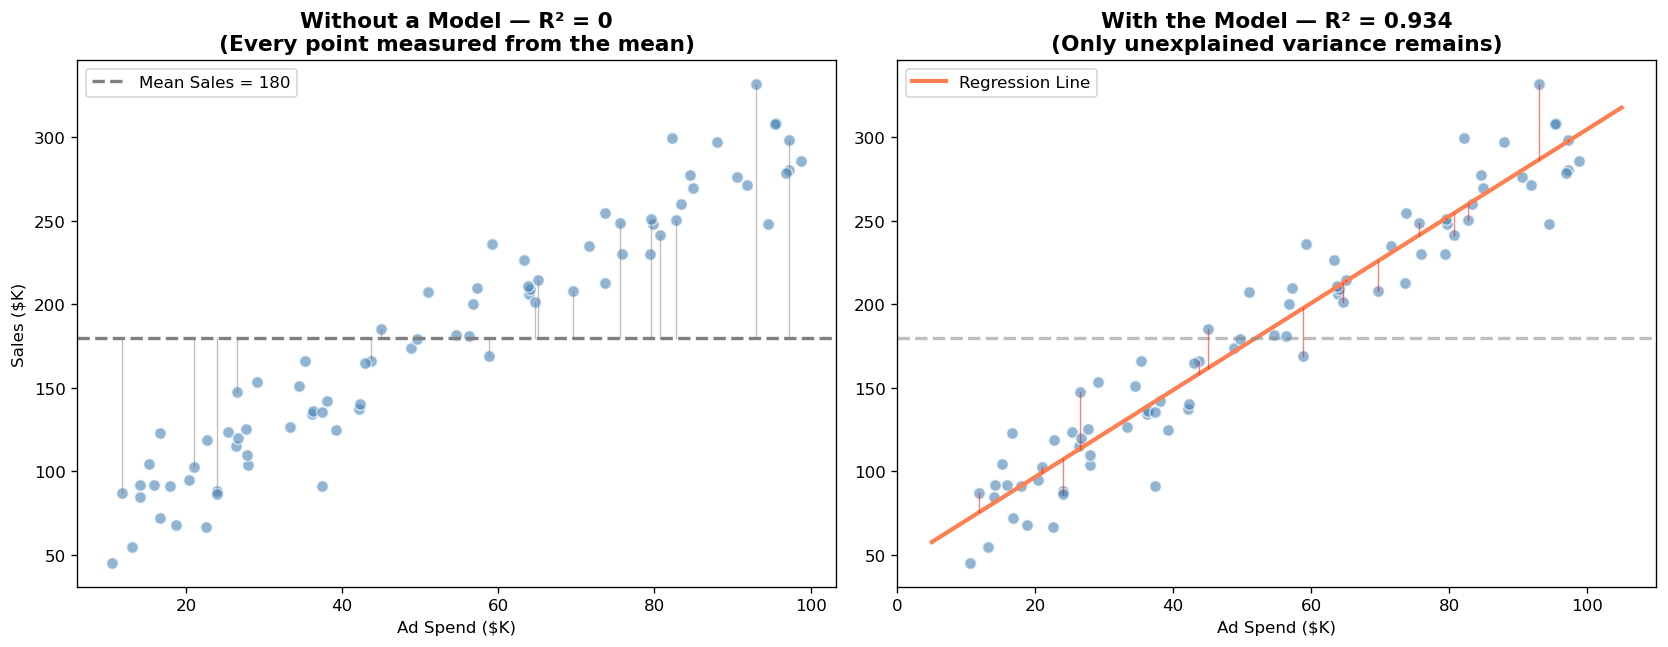

R² = 0.934
The model explains 93.4% of the variation in sales.
The remaining 6.6% is unexplained (noise, other factors).


In [7]:
# R² visual: what "variance explained" means
np.random.seed(42)
ad_spend = np.random.uniform(10, 100, 80)
sales = 50 + 2.5 * ad_spend + np.random.normal(0, 20, 80)
X = ad_spend.reshape(-1, 1)
model = LinearRegression()
model.fit(X, sales)
predicted = model.predict(X)
mean_sales = np.mean(sales)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: total variance (distance from mean)
axes[0].scatter(ad_spend, sales, color='steelblue', alpha=0.6, edgecolor='white', s=50)
axes[0].axhline(mean_sales, color='gray', linewidth=2, linestyle='--',
                label=f'Mean Sales = {mean_sales:.0f}')
for i in range(0, len(ad_spend), 5):
    axes[0].plot([ad_spend[i], ad_spend[i]], [sales[i], mean_sales],
                 color='gray', linewidth=0.8, alpha=0.5)
axes[0].set_title('Without a Model — R² = 0\n(Every point measured from the mean)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ad Spend ($K)')
axes[0].set_ylabel('Sales ($K)')
axes[0].legend(fontsize=10)

# Right: explained vs unexplained
line_x = np.linspace(5, 105, 100)
line_y = model.predict(line_x.reshape(-1, 1))
axes[1].scatter(ad_spend, sales, color='steelblue', alpha=0.6, edgecolor='white', s=50)
axes[1].plot(line_x, line_y, color='coral', linewidth=2.5, label='Regression Line')
axes[1].axhline(mean_sales, color='gray', linewidth=2, linestyle='--', alpha=0.5)
for i in range(0, len(ad_spend), 5):
    axes[1].plot([ad_spend[i], ad_spend[i]], [sales[i], predicted[i]],
                 color='red', linewidth=0.8, alpha=0.5)
r2 = r2_score(sales, predicted)
axes[1].set_title(f'With the Model — R² = {r2:.3f}\n(Only unexplained variance remains)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ad Spend ($K)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"R² = {r2:.3f}")
print(f"The model explains {r2*100:.1f}% of the variation in sales.")
print(f"The remaining {(1-r2)*100:.1f}% is unexplained (noise, other factors).")

### What Does "Variance Explained" Actually Mean?

**Variance** = how spread out the data is. **"Explained"** = the model accounts for *why* values differ.

Think of it this way:
- **Without a model**, your best guess for any data point is the overall mean. All variation is "unexplained."
- **With a model**, variation is split into two parts: what the model *explains* (the trend) and what's *left over* (the residuals).

R² is the fraction your model solved: $R^2 = 1 - \frac{\text{Unexplained variance}}{\text{Total variance}}$

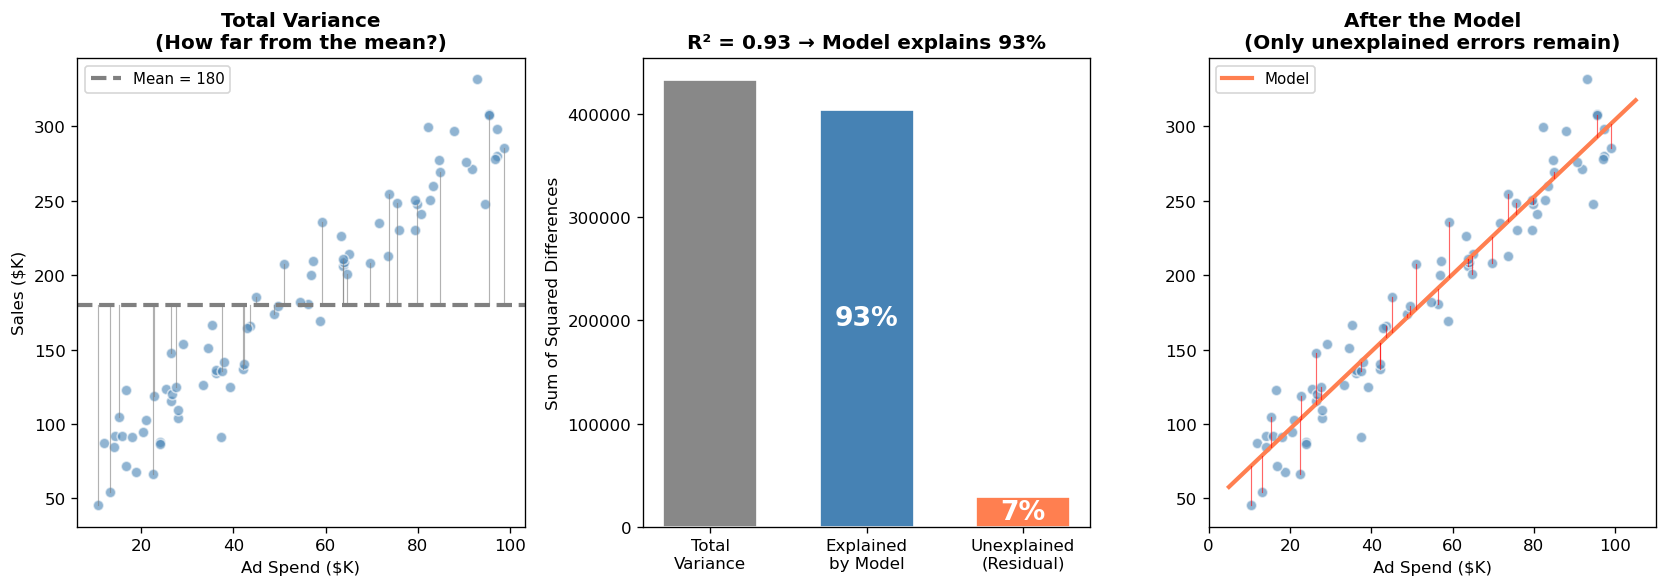

Total variance (SS_total):     432,947
Explained by model:            404,191  (93%)
Unexplained (residual):        28,756  (7%)


In [8]:
# Variance decomposition — three views
np.random.seed(42)
x = np.random.uniform(10, 100, 80)
y = 50 + 2.5 * x + np.random.normal(0, 20, 80)
model = LinearRegression().fit(x.reshape(-1, 1), y)
pred = model.predict(x.reshape(-1, 1))
mean_y = np.mean(y)

SS_total = np.sum((y - mean_y)**2)
SS_residual = np.sum((y - pred)**2)
SS_explained = SS_total - SS_residual
r2 = SS_explained / SS_total

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Left: total variance
axes[0].scatter(x, y, color='steelblue', alpha=0.6, s=40, edgecolor='white')
axes[0].axhline(mean_y, color='gray', linewidth=2.5, linestyle='--', label=f'Mean = {mean_y:.0f}')
for i in range(0, len(x), 3):
    axes[0].plot([x[i], x[i]], [y[i], mean_y], color='gray', linewidth=0.7, alpha=0.6)
axes[0].set_title('Total Variance\n(How far from the mean?)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ad Spend ($K)')
axes[0].set_ylabel('Sales ($K)')
axes[0].legend(fontsize=9)

# Center: decomposition bar chart
bars = axes[1].bar(['Total\nVariance', 'Explained\nby Model', 'Unexplained\n(Residual)'],
       [SS_total, SS_explained, SS_residual],
       color=['#888888', 'steelblue', 'coral'], edgecolor='white', width=0.6)
axes[1].set_ylabel('Sum of Squared Differences', fontsize=10)
axes[1].set_title(f'R² = {r2:.2f} → Model explains {r2*100:.0f}%', fontsize=12, fontweight='bold')
axes[1].text(1, SS_explained/2, f'{r2*100:.0f}%', ha='center', va='center',
             fontsize=16, fontweight='bold', color='white')
axes[1].text(2, SS_residual/2, f'{(1-r2)*100:.0f}%', ha='center', va='center',
             fontsize=16, fontweight='bold', color='white')

# Right: after model
lx = np.linspace(5, 105, 100)
ly = model.predict(lx.reshape(-1, 1))
axes[2].scatter(x, y, color='steelblue', alpha=0.6, s=40, edgecolor='white')
axes[2].plot(lx, ly, color='coral', linewidth=2.5, label='Model')
for i in range(0, len(x), 3):
    axes[2].plot([x[i], x[i]], [y[i], pred[i]], color='red', linewidth=0.7, alpha=0.6)
axes[2].set_title('After the Model\n(Only unexplained errors remain)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Ad Spend ($K)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total variance (SS_total):     {SS_total:,.0f}")
print(f"Explained by model:            {SS_explained:,.0f}  ({r2*100:.0f}%)")
print(f"Unexplained (residual):        {SS_residual:,.0f}  ({(1-r2)*100:.0f}%)")

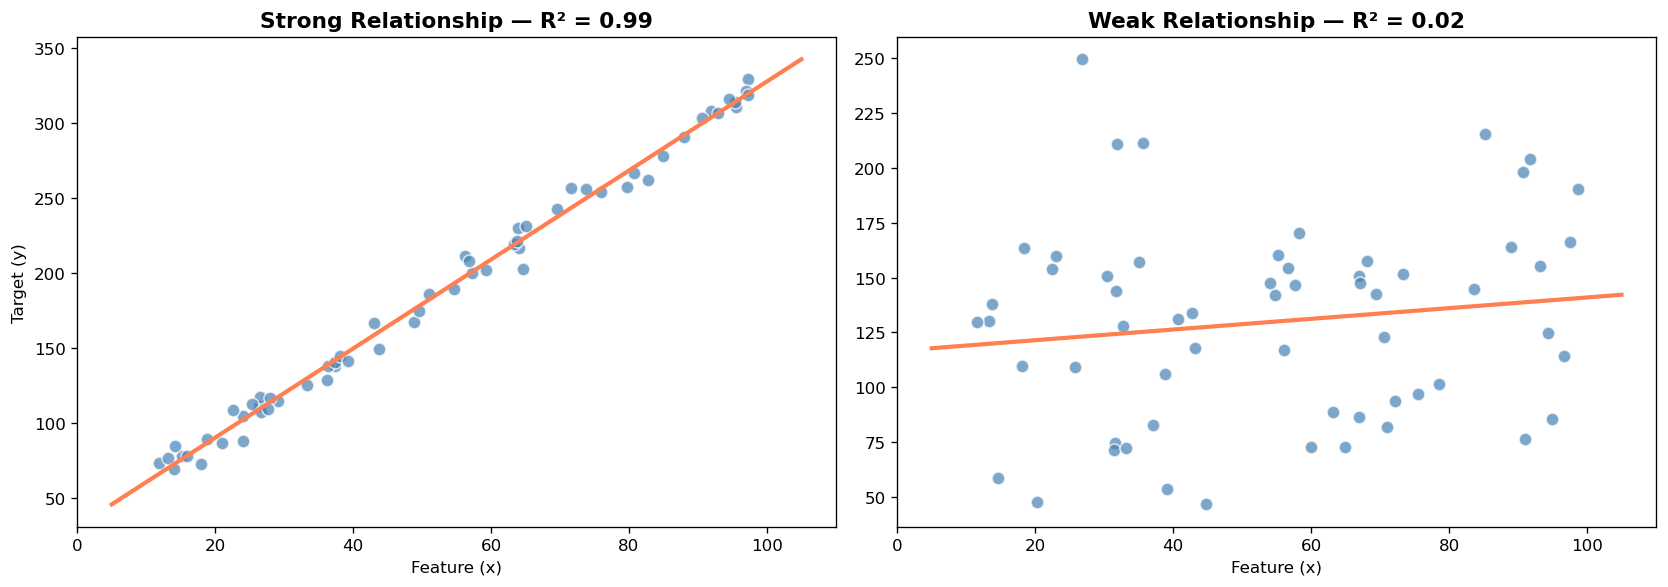

Left:  Points hug the line → R² = 0.99 (model explains 99%)
Right: Points are scattered → R² = 0.02 (model explains only 2%)


In [9]:
# R² Visual — what high vs. low R² looks like
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lx = np.linspace(5, 105, 100)

# High R²: tight scatter around the line
x_high = np.random.uniform(10, 100, 60)
y_high = 30 + 3.0 * x_high + np.random.normal(0, 8, 60)
m_h = LinearRegression().fit(x_high.reshape(-1, 1), y_high)
axes[0].scatter(x_high, y_high, color='steelblue', alpha=0.7, edgecolor='white', s=60)
axes[0].plot(lx, m_h.predict(lx.reshape(-1, 1)), color='coral', linewidth=2.5)
r2_h = r2_score(y_high, m_h.predict(x_high.reshape(-1, 1)))
axes[0].set_title(f'Strong Relationship — R² = {r2_h:.2f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature (x)'); axes[0].set_ylabel('Target (y)')

# Low R²: wide scatter, line barely helps
x_low = np.random.uniform(10, 100, 60)
y_low = 100 + 0.5 * x_low + np.random.normal(0, 50, 60)
m_l = LinearRegression().fit(x_low.reshape(-1, 1), y_low)
axes[1].scatter(x_low, y_low, color='steelblue', alpha=0.7, edgecolor='white', s=60)
axes[1].plot(lx, m_l.predict(lx.reshape(-1, 1)), color='coral', linewidth=2.5)
r2_l = r2_score(y_low, m_l.predict(x_low.reshape(-1, 1)))
axes[1].set_title(f'Weak Relationship — R² = {r2_l:.2f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature (x)')

plt.tight_layout()
plt.show()

print(f"Left:  Points hug the line → R² = {r2_h:.2f} (model explains {r2_h*100:.0f}%)")
print(f"Right: Points are scattered → R² = {r2_l:.2f} (model explains only {r2_l*100:.0f}%)")

### RMSE — Error in the Units You Care About

R² tells you the *proportion* of variance explained. **RMSE** tells you the *average prediction error* in the original units:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

| Model | RMSE | Interpretation |
|:------|:-----|:---------------|
| Sales prediction | $12.3K | "Our predictions are off by about $12.3K on average" |
| House pricing | $28,500 | "We're typically wrong by about $28,500" |
| Delivery time | 4.2 min | "We predict delivery within about 4 minutes" |

**Lower RMSE = better predictions.** Unlike R², RMSE has units — which makes it easier to explain to stakeholders.

### Interpreting R²

| R² Value | Quality | What It Means |
|:---------|:--------|:--------------|
| 0.90+ | Excellent | Explains 90%+ of variation — rare in business |
| 0.70–0.90 | Good | Strong predictive power — useful for decisions |
| 0.50–0.70 | Moderate | Helpful, but significant unexplained variation |
| 0.30–0.50 | Weak | Some signal, but too noisy for reliable predictions |
| < 0.30 | Poor | Misses most of the variation — rethink your approach |

**Context matters:** R² of 0.40 predicting stock prices might be amazing. R² of 0.40 in a physics experiment would be terrible.

---

## 12.5 Transformations, Overfitting, and Train-Test Split

### What If the Relationship Isn't a Straight Line?

Real-world data often curves. A **polynomial** adds powers of x (x², x³, ...) to capture bends and wiggles. Higher orders = more bends:

- **1st order (linear):** y = β₀ + β₁x → a straight line (0 bends)
- **2nd order (quadratic):** y = β₀ + β₁x + β₂x² → one bend (a parabola)
- **3rd order (cubic):** y = β₀ + β₁x + β₂x² + β₃x³ → two bends

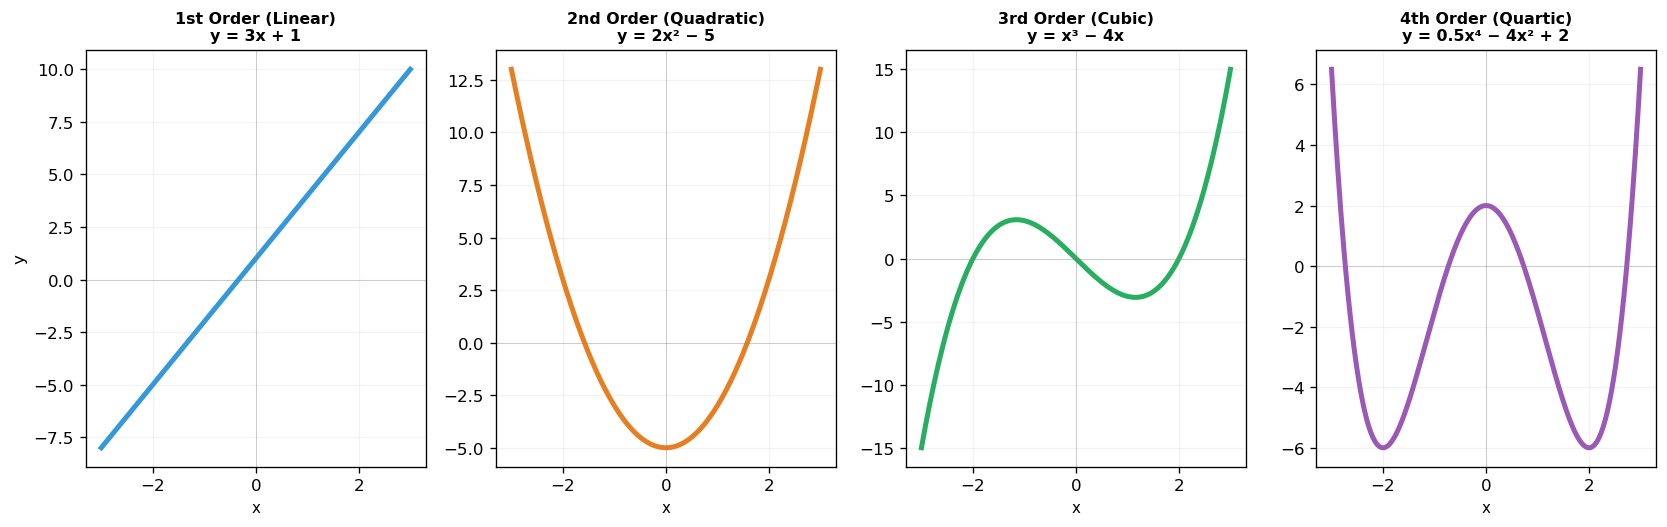

Each additional order adds one possible bend — and one more coefficient to interpret.


In [10]:
# What polynomial curves look like
x_demo = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
polys = [
    (lambda x: 3*x + 1,                '1st Order (Linear)\ny = 3x + 1',   '#3498db'),
    (lambda x: 2*x**2 - 5,             '2nd Order (Quadratic)\ny = 2x² − 5', '#e67e22'),
    (lambda x: x**3 - 4*x,             '3rd Order (Cubic)\ny = x³ − 4x',   '#27ae60'),
    (lambda x: 0.5*x**4 - 4*x**2 + 2, '4th Order (Quartic)\ny = 0.5x⁴ − 4x² + 2', '#9b59b6'),
]
for ax, (fn, title, clr) in zip(axes, polys):
    ax.plot(x_demo, fn(x_demo), color=clr, linewidth=3)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.set_xlabel('x', fontsize=9)
    ax.grid(True, alpha=0.15)
axes[0].set_ylabel('y', fontsize=10)
plt.tight_layout()
plt.show()

print("Each additional order adds one possible bend — and one more coefficient to interpret.")

### The Transformation Trick — Staying "Linear"

**Key insight:** "Linear regression" means linear *in the coefficients*, not in x. We can create new features from powers of x and still use the same `LinearRegression()`:

1. Start with feature `x`
2. Create `x²` as a new column
3. Feed both `x` and `x²` to LinearRegression
4. The model fits: y = β₀ + β₁·x + β₂·x² — which is a curve!

**It's still a linear model** (linear in β₀, β₁, β₂) but it fits a **curved relationship** in x.

Original feature vs. transformed features:
   x   x²
0.21 0.04
0.46 0.22
0.58 0.34
0.65 0.42
0.98 0.95
1.39 1.95
1.56 2.43
1.56 2.43


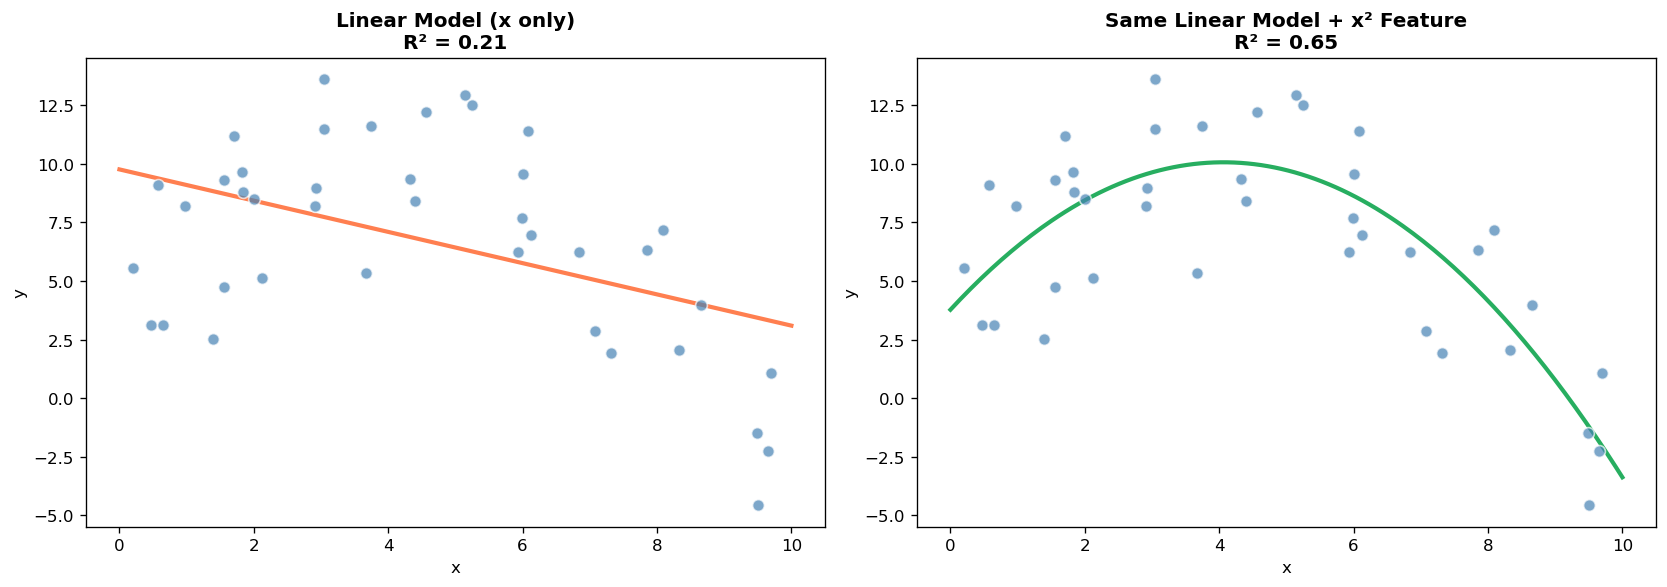


Linear only:  R² = 0.21
With x² added: R² = 0.65

Adding the x² feature lets the SAME LinearRegression() fit the curve!


In [11]:
# The transformation trick: same LinearRegression, curved fit
np.random.seed(42)
x = np.sort(np.random.uniform(0, 10, 40))
y = 5 + 3*x - 0.4*x**2 + np.random.normal(0, 3, 40)

# Transform: create polynomial features from x
X_poly = pd.DataFrame({'x': x, 'x²': x**2})
print("Original feature vs. transformed features:")
print(X_poly.head(8).to_string(index=False))

# Fit both models
model_linear = LinearRegression().fit(x.reshape(-1, 1), y)
model_poly = LinearRegression().fit(X_poly, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_smooth = np.linspace(0, 10, 200)

# Left: linear only
axes[0].scatter(x, y, color='steelblue', alpha=0.7, s=50, edgecolor='white', zorder=5)
axes[0].plot(x_smooth, model_linear.predict(x_smooth.reshape(-1, 1)), color='coral', linewidth=2.5)
r2_lin = r2_score(y, model_linear.predict(x.reshape(-1, 1)))
axes[0].set_title(f'Linear Model (x only)\nR² = {r2_lin:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Right: polynomial features
X_smooth = pd.DataFrame({'x': x_smooth, 'x²': x_smooth**2})
axes[1].scatter(x, y, color='steelblue', alpha=0.7, s=50, edgecolor='white', zorder=5)
axes[1].plot(x_smooth, model_poly.predict(X_smooth), color='#27ae60', linewidth=2.5)
r2_poly = r2_score(y, model_poly.predict(X_poly))
axes[1].set_title(f'Same Linear Model + x² Feature\nR² = {r2_poly:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

print(f"\nLinear only:  R² = {r2_lin:.2f}")
print(f"With x² added: R² = {r2_poly:.2f}")
print(f"\nAdding the x² feature lets the SAME LinearRegression() fit the curve!")

### Overfitting — When the Model Memorizes Instead of Learning

**But beware:** adding too many powers (x³, x⁴, ... x²⁰) can lead to **overfitting** — the model memorizes the training data's noise instead of learning the real pattern.

An overfit model looks great on training data but performs terribly on new data it hasn't seen before.

/tmp/ipykernel_17672/3647475339.py:26: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train, y_train, deg)


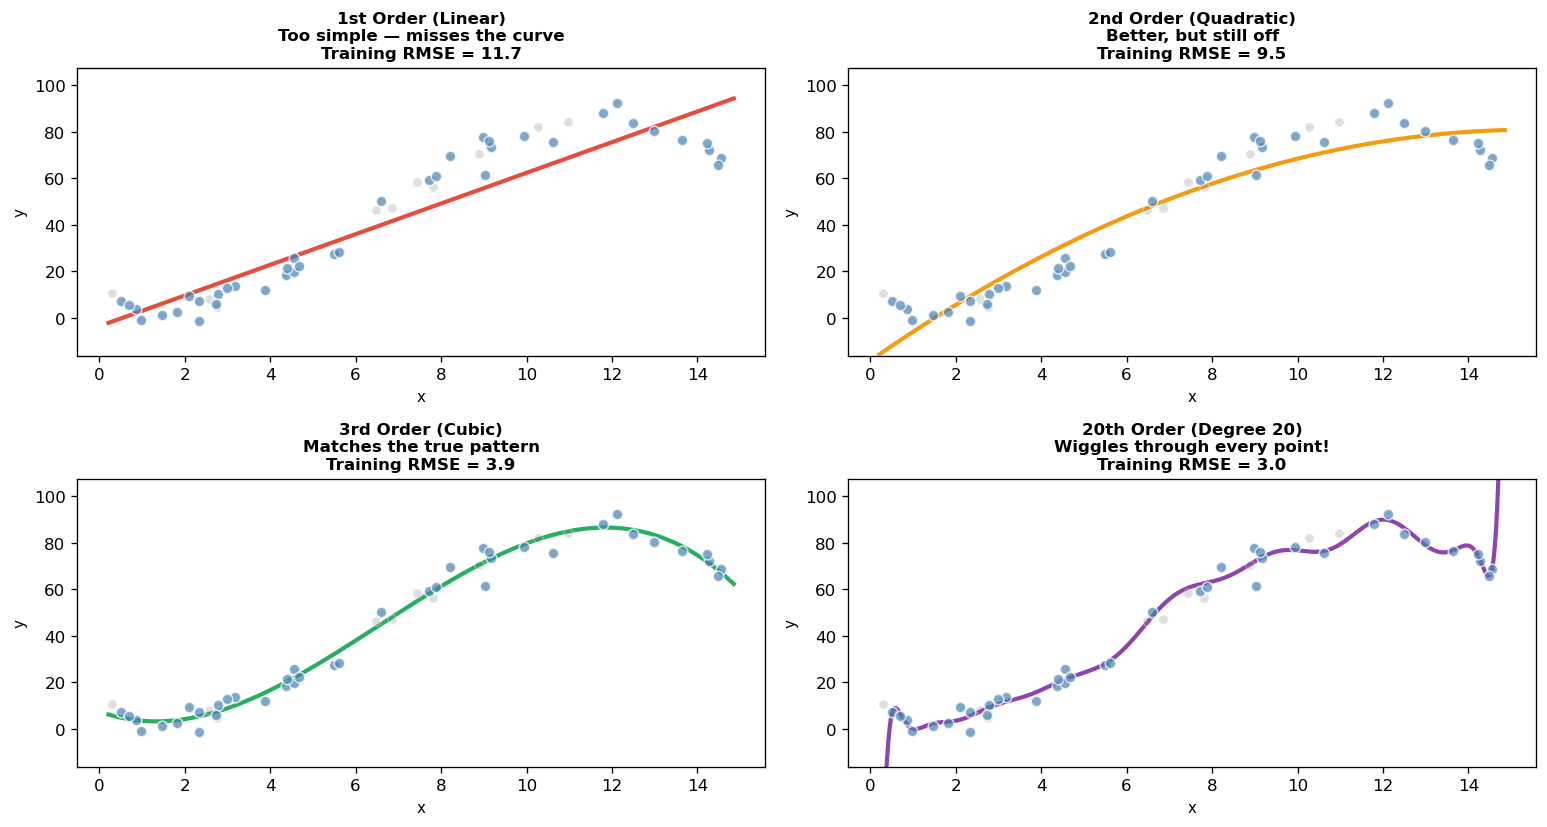

Blue dots = training data. Gray dots = held-out test data.

The 20th order polynomial has the LOWEST training RMSE — it fits training data almost perfectly.
But look at those wild wiggles! It's memorizing noise, not learning the real pattern.
This is OVERFITTING.


In [12]:
# Overfitting demo: 1st, 2nd, 3rd, and 20th order polynomials
np.random.seed(42)
n = 50
x_poly = np.sort(np.random.uniform(0, 15, n))
y_true = 10 - 8*x_poly + 3*x_poly**2 - 0.15*x_poly**3
y_poly = y_true + np.random.normal(0, 4, n)

# 80/20 split
idx = np.arange(n)
np.random.shuffle(idx)
train_idx, test_idx = idx[:40], idx[40:]
x_train, y_train = x_poly[train_idx], y_poly[train_idx]
x_test, y_test = x_poly[test_idx], y_poly[test_idx]

degrees = [1, 2, 3, 20]
titles = ['1st Order (Linear)\nToo simple — misses the curve',
          '2nd Order (Quadratic)\nBetter, but still off',
          '3rd Order (Cubic)\nMatches the true pattern',
          '20th Order (Degree 20)\nWiggles through every point!']
colors = ['#e74c3c', '#f39c12', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
x_smooth = np.linspace(x_train.min() - 0.3, x_train.max() + 0.3, 500)

for ax, deg, title, clr in zip(axes.flat, degrees, titles, colors):
    coeffs = np.polyfit(x_train, y_train, deg)
    y_fit_train = np.polyval(coeffs, x_train)
    y_smooth = np.polyval(coeffs, x_smooth)
    rmse = np.sqrt(np.mean((y_train - y_fit_train)**2))

    ax.scatter(x_train, y_train, color='steelblue', alpha=0.7, s=40, edgecolor='white', zorder=5)
    ax.scatter(x_test, y_test, color='gray', alpha=0.25, s=30, edgecolor='white', zorder=4)
    y_clip = np.clip(y_smooth, min(y_poly) - 20, max(y_poly) + 20)
    ax.plot(x_smooth, y_clip, color=clr, linewidth=2.5)
    ax.set_ylim(min(y_poly) - 15, max(y_poly) + 15)
    ax.set_title(f'{title}\nTraining RMSE = {rmse:.1f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('x', fontsize=9); ax.set_ylabel('y', fontsize=9)

plt.tight_layout()
plt.show()

print("Blue dots = training data. Gray dots = held-out test data.")
print("\nThe 20th order polynomial has the LOWEST training RMSE — it fits training data almost perfectly.")
print("But look at those wild wiggles! It's memorizing noise, not learning the real pattern.")
print("This is OVERFITTING.")

### Train-Test Split — The Guard Against Overfitting

How do we catch overfitting? **Split the data before training.** Train on one portion, test on the held-out portion the model has never seen. If a model is overfit, its test error will be much worse than its training error.

/tmp/ipykernel_17672/2898731548.py:19: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train, y_train, deg)


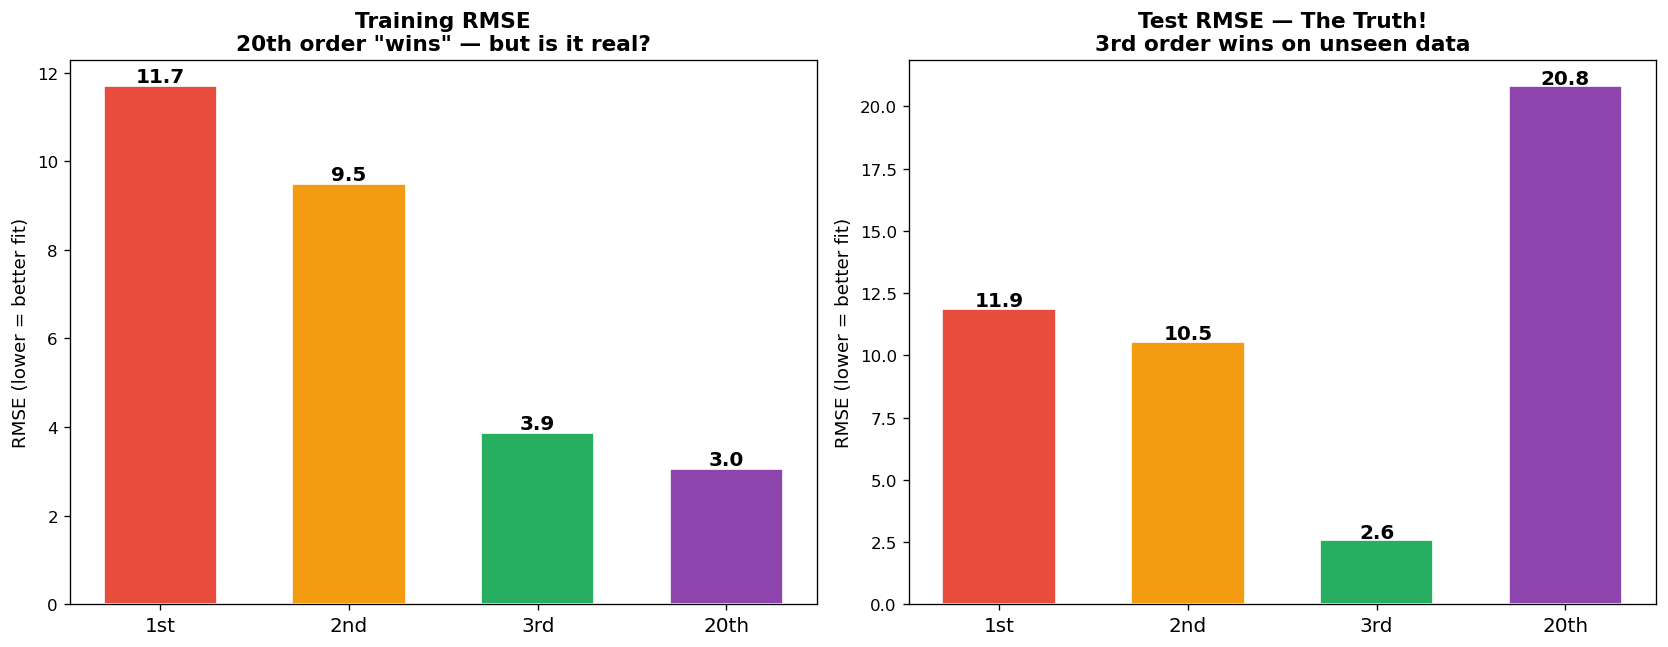

Left:  On TRAINING data, the 20th order polynomial looks best (lowest RMSE).
Right: On TEST data (never seen before), it's the WORST — the wiggles don't generalize.

The 3rd order polynomial (the true relationship) wins on unseen data.

Lesson: ALWAYS evaluate on held-out test data.
That's why every scikit-learn workflow starts with train_test_split().


In [13]:
# Training RMSE vs Test RMSE — the truth about overfitting
np.random.seed(42)
n = 50
x_poly = np.sort(np.random.uniform(0, 15, n))
y_true = 10 - 8*x_poly + 3*x_poly**2 - 0.15*x_poly**3
y_poly = y_true + np.random.normal(0, 4, n)

idx = np.arange(n)
np.random.shuffle(idx)
train_idx, test_idx = idx[:40], idx[40:]
x_train, y_train = x_poly[train_idx], y_poly[train_idx]
x_test, y_test = x_poly[test_idx], y_poly[test_idx]

degrees = [1, 2, 3, 20]
labels = ['1st', '2nd', '3rd', '20th']
train_rmses, test_rmses = [], []

for deg in degrees:
    coeffs = np.polyfit(x_train, y_train, deg)
    train_rmses.append(np.sqrt(np.mean((y_train - np.polyval(coeffs, x_train))**2)))
    test_rmses.append(np.sqrt(np.mean((y_test - np.polyval(coeffs, x_test))**2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x_pos = np.arange(len(degrees))

# Left: training RMSE
bars1 = axes[0].bar(x_pos, train_rmses, color=['#e74c3c', '#f39c12', '#27ae60', '#8e44ad'],
                     width=0.6, edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylabel('RMSE (lower = better fit)', fontsize=11)
axes[0].set_title('Training RMSE\n20th order "wins" — but is it real?', fontsize=13, fontweight='bold')
for bar, val in zip(bars1, train_rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

# Right: test RMSE
bars2 = axes[1].bar(x_pos, test_rmses, color=['#e74c3c', '#f39c12', '#27ae60', '#8e44ad'],
                     width=0.6, edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel('RMSE (lower = better fit)', fontsize=11)
axes[1].set_title('Test RMSE — The Truth!\n3rd order wins on unseen data', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, test_rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Left:  On TRAINING data, the 20th order polynomial looks best (lowest RMSE).")
print("Right: On TEST data (never seen before), it's the WORST — the wiggles don't generalize.")
print("\nThe 3rd order polynomial (the true relationship) wins on unseen data.")
print("\nLesson: ALWAYS evaluate on held-out test data.")
print("That's why every scikit-learn workflow starts with train_test_split().")

---

## 12.6 The scikit-learn Workflow

Every regression project in scikit-learn follows the same five steps:

| Step | Action | Code |
|:-----|:-------|:-----|
| 1. Prepare | Select features, define target | `X = df[['feature']]`; `y = df['target']` |
| 2. Split | Hold out test data | `train_test_split(X, y, test_size=0.2)` |
| 3. Train | Fit model on training data | `model.fit(X_train, y_train)` |
| 4. Predict | Generate predictions | `y_pred = model.predict(X_test)` |
| 5. Evaluate | Measure accuracy | `r2_score(y_test, y_pred)`, `mean_squared_error(...)` |

**Key rule:** X must be 2D. Use `df[['col']]` (double brackets) not `df['col']`.

Let's apply this workflow to real business data.

In [14]:
# Load advertising sales data
ad_sales = pd.read_csv(f"{DATA_URL}/W12/advertising_sales.csv")

print("ADVERTISING SALES DATA")
print("=" * 50)
print(f"Shape: {ad_sales.shape[0]} rows × {ad_sales.shape[1]} columns")
print(f"\nColumns: {list(ad_sales.columns)}")
print(f"\nFirst 5 rows:")
ad_sales.head()

ADVERTISING SALES DATA
Shape: 150 rows × 2 columns

Columns: ['Ad_Spend', 'Sales']

First 5 rows:


,Ad_Spend,Sales
0,40.58,147.60
1,95.32,294.33
2,74.54,235.66
3,61.87,181.30
4,19.82,122.41


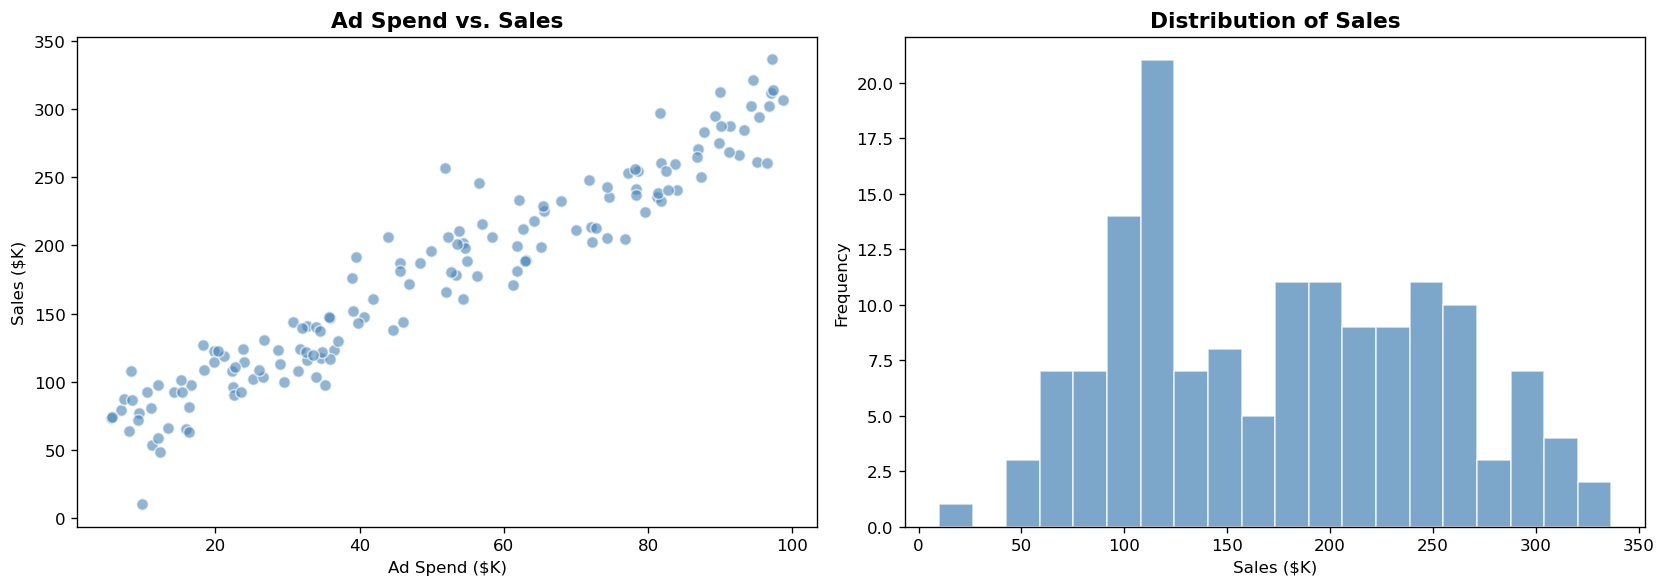

Correlation between Ad_Spend and Sales: 0.961

Summary statistics:


,Ad_Spend,Sales
count,150.00,150.00
mean,49.92,175.75
std,28.17,74.38
min,5.52,9.90
25%,25.40,113.08
50%,47.57,178.06
75%,76.22,236.52
max,98.75,336.66


In [15]:
# Step 1: Explore the data visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(ad_sales['Ad_Spend'], ad_sales['Sales'], color='steelblue',
                alpha=0.6, edgecolor='white', s=50)
axes[0].set_title('Ad Spend vs. Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ad Spend ($K)')
axes[0].set_ylabel('Sales ($K)')

# Distributions
axes[1].hist(ad_sales['Sales'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].set_title('Distribution of Sales', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sales ($K)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

corr = ad_sales['Ad_Spend'].corr(ad_sales['Sales'])
print(f"Correlation between Ad_Spend and Sales: {corr:.3f}")
print(f"\nSummary statistics:")
ad_sales.describe().round(2)

In [16]:
# Step 2: Prepare features and target
X = ad_sales[['Ad_Spend']]  # 2D — double brackets!
y = ad_sales['Sales']

print(f"X shape: {X.shape}  ← must be 2D: (n_samples, n_features)")
print(f"y shape: {y.shape}  ← 1D: (n_samples,)")

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

X shape: (150, 1)  ← must be 2D: (n_samples, n_features)
y shape: (150,)  ← 1D: (n_samples,)

Training set: 120 samples (80%)
Testing set:  30 samples (20%)


In [17]:
# Step 4: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("MODEL TRAINED!")
print("=" * 50)
print(f"Intercept (β₀): {model.intercept_:.2f}")
print(f"Slope (β₁):     {model.coef_[0]:.2f}")
print(f"\nEquation: Sales = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Ad_Spend")
print(f"\nInterpretation:")
print(f"  • Baseline sales (no ad spend): ${model.intercept_:,.0f}K")
print(f"  • Each additional $1K in ad spend → ${model.coef_[0]:,.2f}K more in sales")

MODEL TRAINED!
Intercept (β₀): 49.00
Slope (β₁):     2.56

Equation: Sales = 49.00 + 2.56 × Ad_Spend

Interpretation:
  • Baseline sales (no ad spend): $49K
  • Each additional $1K in ad spend → $2.56K more in sales


MODEL EVALUATION (on test data)
R² Score:  0.965
RMSE:      $13.78K

Interpretation:
  • The model explains 96.5% of the variance in Sales
  • Predictions are off by about $13.8K on average


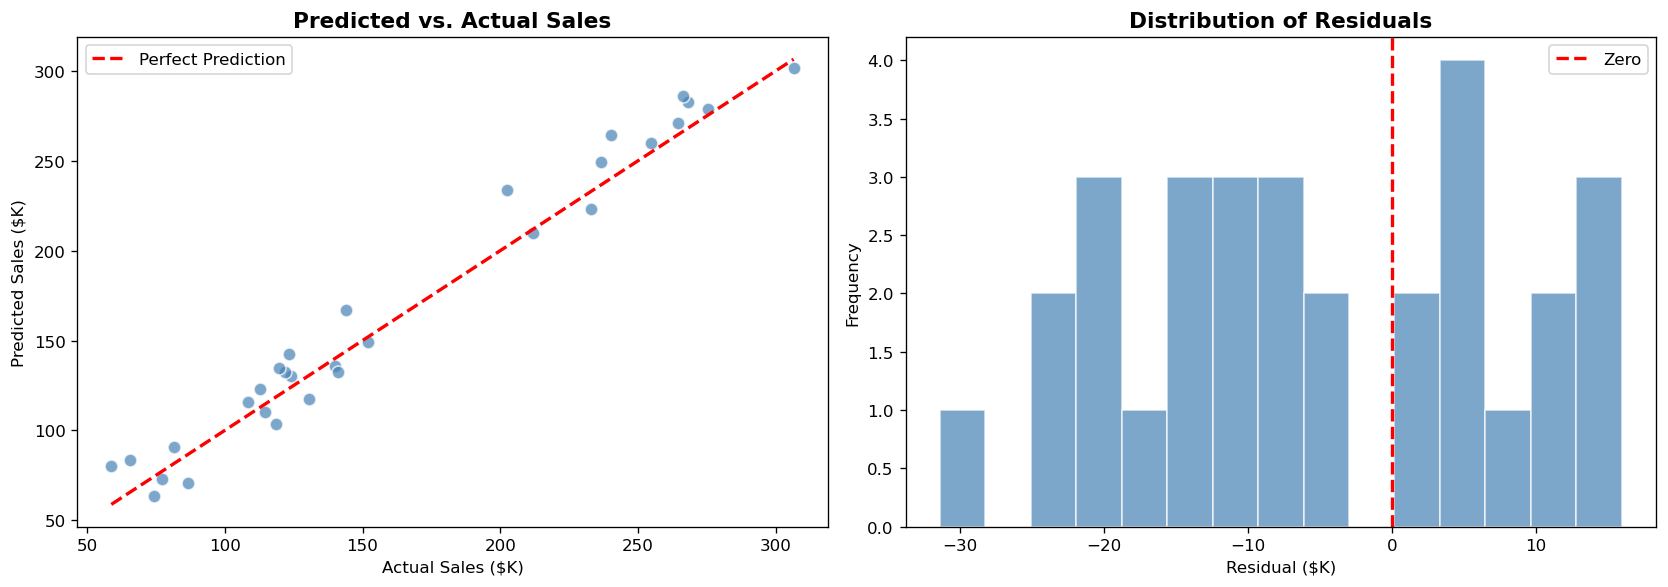

In [18]:
# Step 5: Evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MODEL EVALUATION (on test data)")
print("=" * 50)
print(f"R² Score:  {r2:.3f}")
print(f"RMSE:      ${rmse:.2f}K")
print(f"\nInterpretation:")
print(f"  • The model explains {r2*100:.1f}% of the variance in Sales")
print(f"  • Predictions are off by about ${rmse:.1f}K on average")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolor='white', s=60)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_title('Predicted vs. Actual Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Sales ($K)')
axes[0].set_ylabel('Predicted Sales ($K)')
axes[0].legend()

# Residuals histogram
residuals = y_test - y_pred
axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero')
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual ($K)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### Making Predictions for New Data

Once the model is trained, you can predict sales for advertising budgets the company hasn't tried yet. This is the whole point — turning past data into future estimates.

SALES PREDICTIONS FOR NEW AD BUDGETS
Model: Sales = 49.00 + 2.56 × Ad_Spend

  Ad Spend: $10K  →  Predicted Sales: $74.6K
  Ad Spend: $25K  →  Predicted Sales: $113.0K
  Ad Spend: $40K  →  Predicted Sales: $151.4K
  Ad Spend: $55K  →  Predicted Sales: $189.8K
  Ad Spend: $75K  →  Predicted Sales: $241.0K
  Ad Spend: $100K  →  Predicted Sales: $305.0K


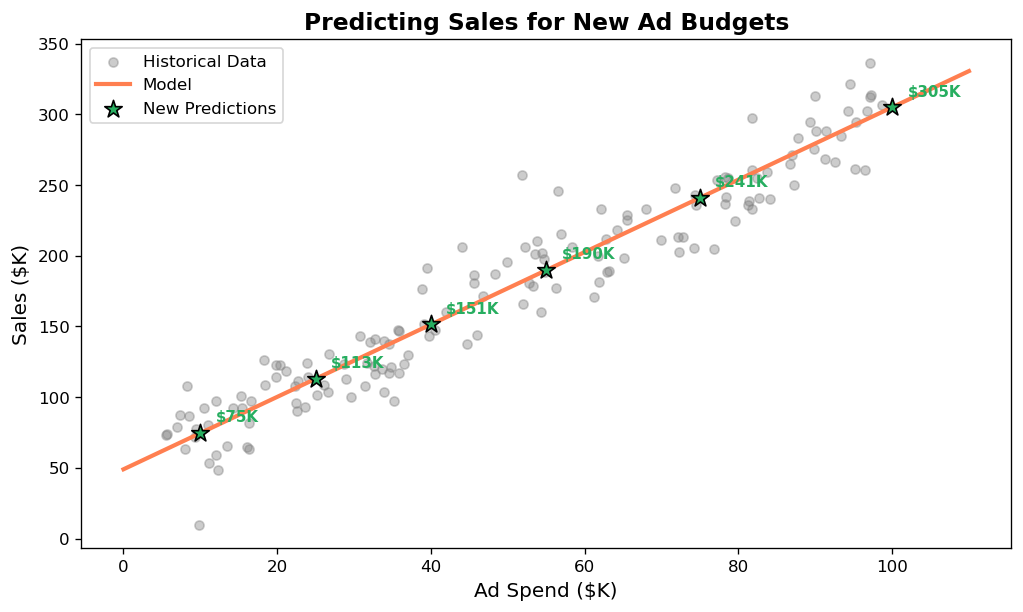

In [19]:
# Predict for new advertising budgets
new_budgets = pd.DataFrame({'Ad_Spend': [10, 25, 40, 55, 75, 100]})
predictions = model.predict(new_budgets)

print("SALES PREDICTIONS FOR NEW AD BUDGETS")
print("=" * 50)
print(f"Model: Sales = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Ad_Spend")
print()
for _, row in new_budgets.iterrows():
    pred = model.predict(pd.DataFrame({'Ad_Spend': [row['Ad_Spend']]}))[0]
    print(f"  Ad Spend: ${row['Ad_Spend']:.0f}K  →  Predicted Sales: ${pred:.1f}K")

# Visualize on the regression line
plt.figure(figsize=(10, 5.5))
plt.scatter(X, y, alpha=0.4, color='gray', s=30, label='Historical Data')
line_x = np.linspace(0, 110, 200)
line_y = model.predict(pd.DataFrame({'Ad_Spend': line_x}))
plt.plot(line_x, line_y, color='coral', linewidth=2.5, label='Model')
plt.scatter(new_budgets['Ad_Spend'], predictions, color='#27ae60', s=120,
            zorder=5, edgecolor='black', marker='*', label='New Predictions')
for i, (spend, pred) in enumerate(zip(new_budgets['Ad_Spend'], predictions)):
    plt.annotate(f'${pred:.0f}K', xy=(spend, pred), xytext=(spend+2, pred+8),
                 fontsize=9, fontweight='bold', color='#27ae60')
plt.title('Predicting Sales for New Ad Budgets', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend ($K)', fontsize=12)
plt.ylabel('Sales ($K)', fontsize=12)
plt.legend(fontsize=10)
plt.show()

---

## 12.7 Multiple Regression — More Features, Better Predictions

Simple regression uses one feature. But outcomes are rarely driven by a single factor. **Multiple regression** adds more features to the equation, letting the model capture more of the signal in the data.

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + ... + \beta_n x_n + \varepsilon$$

Each coefficient tells you: **"Holding all other features constant, a one-unit increase in this feature changes the target by β dollars."**

This "holding constant" idea is what makes multiple regression powerful — it isolates the effect of each feature.

In [20]:
# Load house price data
houses = pd.read_csv(f"{DATA_URL}/W12/house_prices.csv")

print("HOUSE PRICE DATA")
print("=" * 50)
print(f"Shape: {houses.shape[0]} rows × {houses.shape[1]} columns")
print(f"\nColumns: {list(houses.columns)}")
print(f"\nFirst 5 rows:")
houses.head()

HOUSE PRICE DATA
Shape: 300 rows × 5 columns

Columns: ['Sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Price']

First 5 rows:


,Sqft,Bedrooms,Bathrooms,Age,Price
0,1998,2,2,14,520054
1,1744,5,3,30,388080
2,2059,3,1,35,454942
3,2409,2,1,21,516064
4,1706,2,2,37,321150


CORRELATION WITH PRICE
          Sqft: +0.726  ↑
      Bedrooms: +0.356  ↑
     Bathrooms: +0.165  ↑
           Age: -0.346  ↓


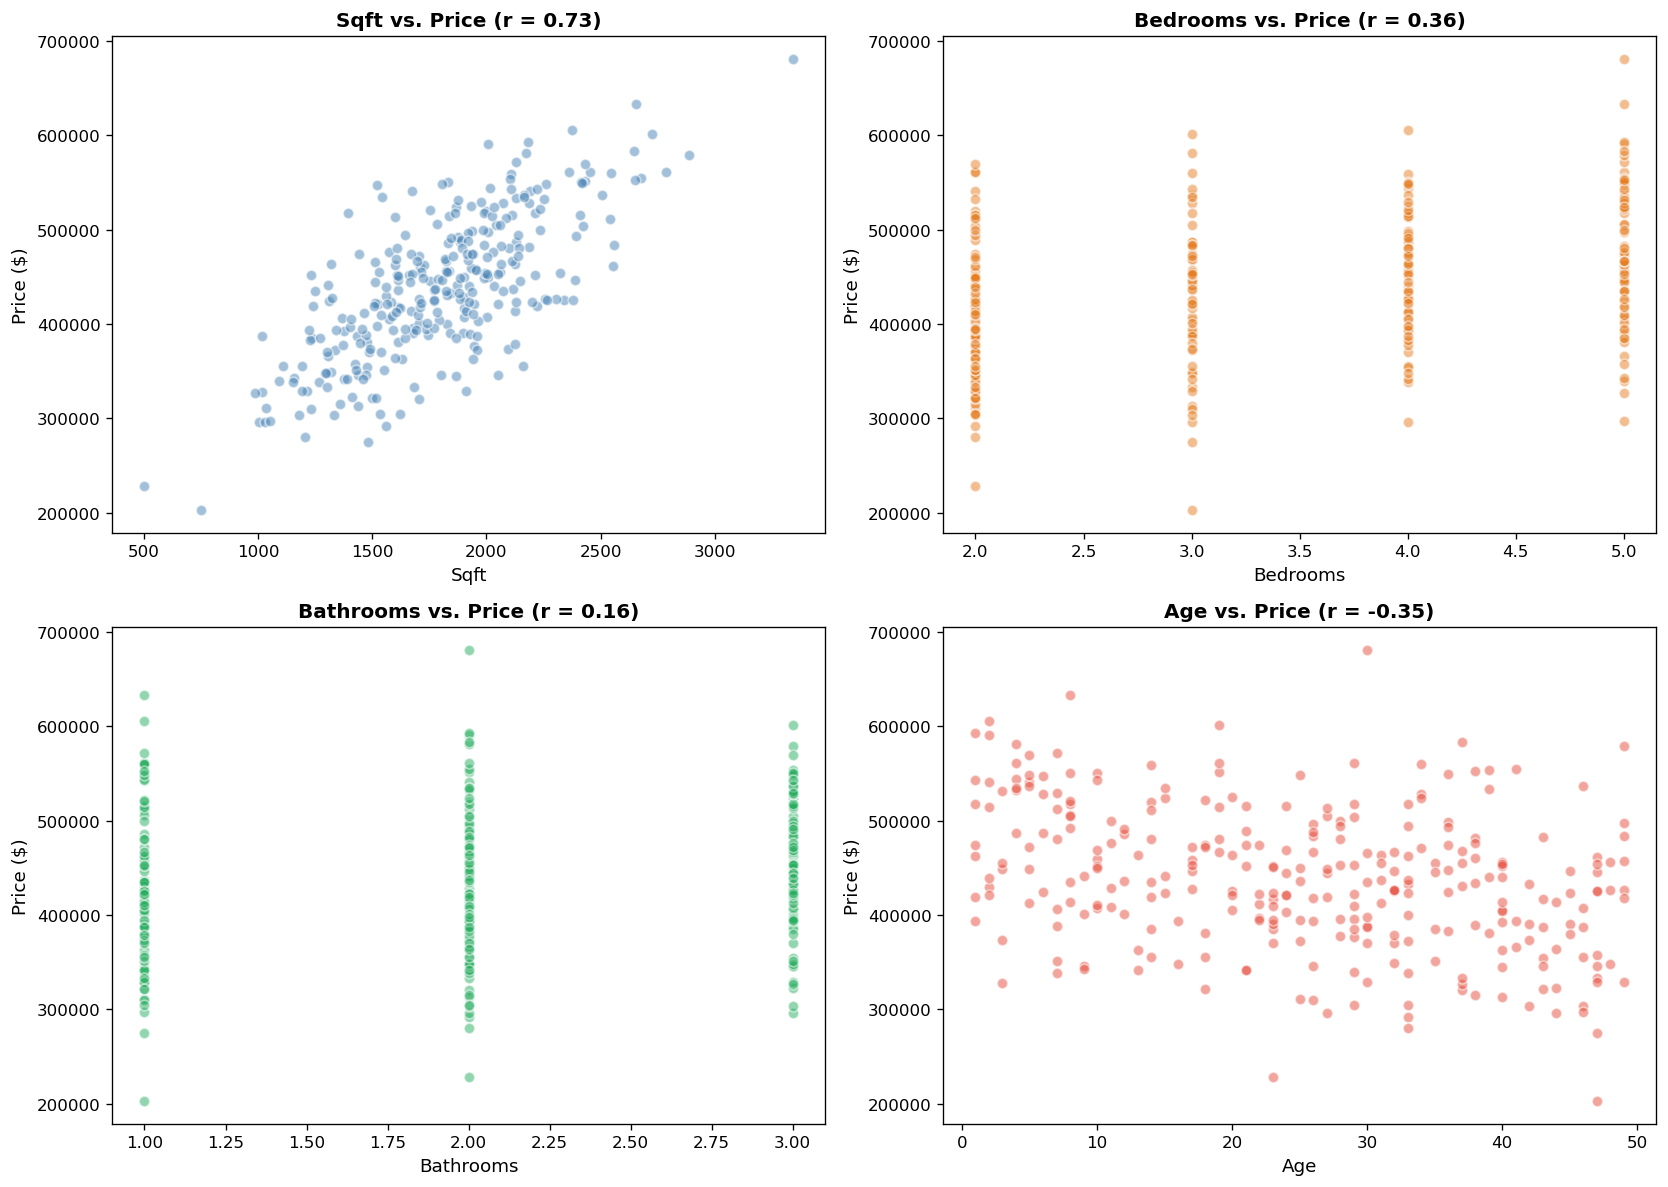

In [21]:
# Explore relationships with the target
print("CORRELATION WITH PRICE")
print("=" * 50)
correlations = houses.corr()['Price'].drop('Price').sort_values(ascending=False)
for feat, corr in correlations.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"  {feat:>12}: {corr:+.3f}  {direction}")

# Visualize all feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
colors = ['steelblue', '#e67e22', '#27ae60', '#e74c3c']

for ax, feat, clr in zip(axes.flat, features, colors):
    ax.scatter(houses[feat], houses['Price'], color=clr, alpha=0.5, edgecolor='white', s=40)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Price ($)', fontsize=11)
    corr = houses[feat].corr(houses['Price'])
    ax.set_title(f'{feat} vs. Price (r = {corr:.2f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Build multiple regression model
feature_columns = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age']
X = houses[feature_columns]
y = houses['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compare: simple (Sqft only) vs. multiple (all features)
simple_model = LinearRegression().fit(X_train[['Sqft']], y_train)
full_model = LinearRegression().fit(X_train, y_train)

r2_simple = r2_score(y_test, simple_model.predict(X_test[['Sqft']]))
r2_full = r2_score(y_test, full_model.predict(X_test))

print("MODEL COMPARISON")
print("=" * 50)
print(f"Sqft only:     R² = {r2_simple:.3f}")
print(f"All features:  R² = {r2_full:.3f}  ← much better!")
print(f"\nImprovement:   +{(r2_full - r2_simple)*100:.1f} percentage points")

print(f"\nFULL MODEL COEFFICIENTS")
print("=" * 50)
print(f"Intercept: ${full_model.intercept_:,.0f}")
for feat, coef in zip(feature_columns, full_model.coef_):
    print(f"  {feat:>10}: ${coef:>10,.2f}")

MODEL COMPARISON
Sqft only:     R² = 0.452
All features:  R² = 0.828  ← much better!

Improvement:   +37.6 percentage points

FULL MODEL COEFFICIENTS
Intercept: $132,305
        Sqft: $    140.02
    Bedrooms: $ 21,245.61
   Bathrooms: $ 17,188.74
         Age: $ -2,091.30


### Interpreting Multiple Regression Coefficients

Each coefficient tells you the *isolated* effect of one feature:

| Feature | Coefficient | What It Means for a Buyer |
|:--------|:------------|:--------------------------|
| Sqft | +$150 | Each additional sqft adds ~$150 to price |
| Bedrooms | +$25,000 | Each extra bedroom adds ~$25K |
| Bathrooms | +$15,000 | Each extra bathroom adds ~$15K |
| Age | −$2,000 | Each year older reduces price by ~$2K |

**Critical phrase:** *"Holding all other features constant..."*

- "A house that is 100 sqft larger — *with the same bedrooms, bathrooms, and age* — costs ~$15,000 more."
- The negative coefficient on Age: older houses are worth less, all else equal.

In [23]:
# Evaluate the full model
y_pred = full_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("FULL MODEL EVALUATION")
print("=" * 50)
print(f"R² Score:  {r2:.3f}")
print(f"RMSE:      ${rmse:,.0f}")
print(f"\nThe model explains {r2*100:.1f}% of price variance.")
print(f"Predictions are off by about ${rmse:,.0f} on average.")

# Predict for specific houses
new_houses = pd.DataFrame({
    'Sqft': [1500, 2200, 3000],
    'Bedrooms': [3, 4, 5],
    'Bathrooms': [2, 2, 3],
    'Age': [5, 15, 30]
})
new_predictions = full_model.predict(new_houses)

print(f"\nPREDICTIONS FOR NEW HOUSES")
print("=" * 50)
for i, (_, row) in enumerate(new_houses.iterrows()):
    print(f"  House {i+1}: {row['Sqft']} sqft, {row['Bedrooms']} bed, "
          f"{row['Bathrooms']} bath, {row['Age']} yrs → ${new_predictions[i]:,.0f}")

FULL MODEL EVALUATION
R² Score:  0.828
RMSE:      $27,963

The model explains 82.8% of price variance.
Predictions are off by about $27,963 on average.

PREDICTIONS FOR NEW HOUSES
  House 1: 1500 sqft, 3 bed, 2 bath, 5 yrs → $429,997
  House 2: 2200 sqft, 4 bed, 2 bath, 15 yrs → $528,346
  House 3: 3000 sqft, 5 bed, 3 bath, 30 yrs → $647,429


### Feature Importance — Which Features Matter Most?

Raw coefficients can't be compared directly because features have different scales (sqft is in thousands, bedrooms is 2-5). **Standardized coefficients** put everything on the same scale for fair comparison.

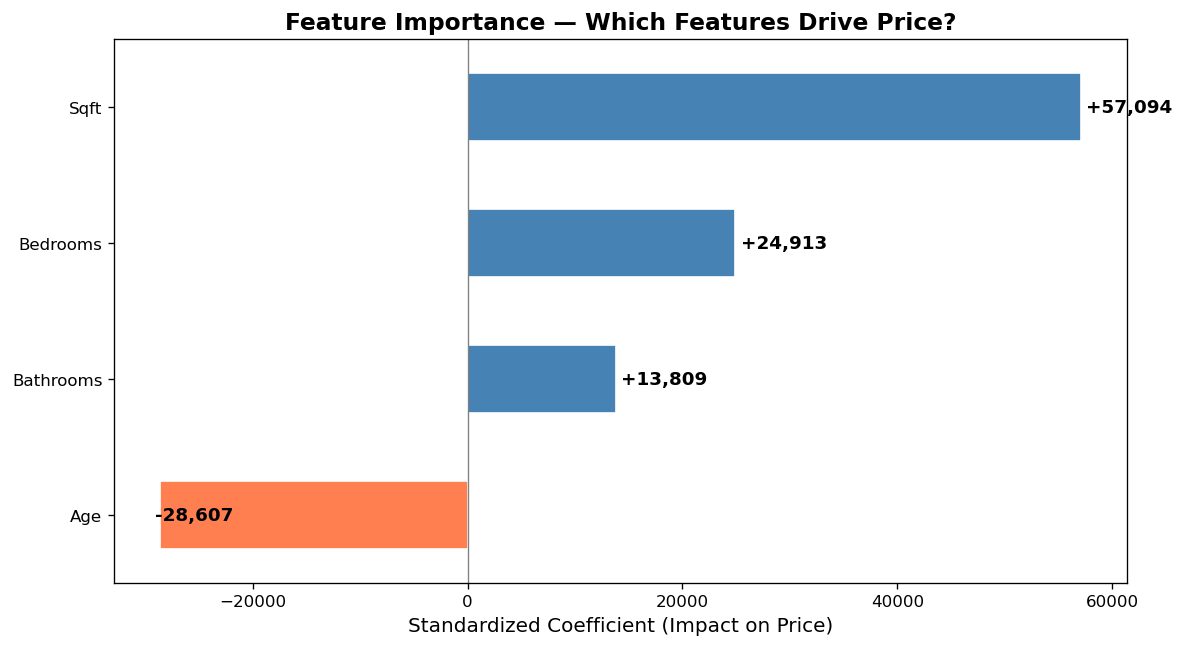

Standardized coefficients show the relative impact of each feature.
Sqft has the largest effect on price. Age has a negative (but smaller) effect.


In [24]:
# Standardized coefficients for fair comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
model_scaled = LinearRegression().fit(X_train_scaled, y_train)

coefs = pd.Series(model_scaled.coef_, index=feature_columns).sort_values()
colors = ['coral' if c < 0 else 'steelblue' for c in coefs]

fig, ax = plt.subplots(figsize=(10, 5.5))
coefs.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_xlabel('Standardized Coefficient (Impact on Price)', fontsize=12)
ax.set_title('Feature Importance — Which Features Drive Price?', fontsize=14, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
for i, (feat, val) in enumerate(coefs.items()):
    ax.text(val + (1 if val >= 0 else -1) * 500, i,
            f'{val:+,.0f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Standardized coefficients show the relative impact of each feature.")
print("Sqft has the largest effect on price. Age has a negative (but smaller) effect.")

---

## 12.8 Assumptions and Residual Analysis

Linear regression makes several key assumptions. You don't need to memorize formulas — just understand the intuition and know how to check them.

| Assumption | What It Means in Practice | How to Check |
|:-----------|:-------------------------|:-------------|
| **Linearity** | The relationship between x and y is approximately a straight line | Scatter plot of x vs y |
| **Independence** | Data points don't influence each other | Know your data collection process |
| **Normal residuals** | Errors form a bell curve around zero | Histogram of residuals |
| **Constant variance** | Error spread is the same across all x values | Residuals vs. predicted plot |

**In practice:** Check the residuals. If they look random and centered on zero, you're usually fine.

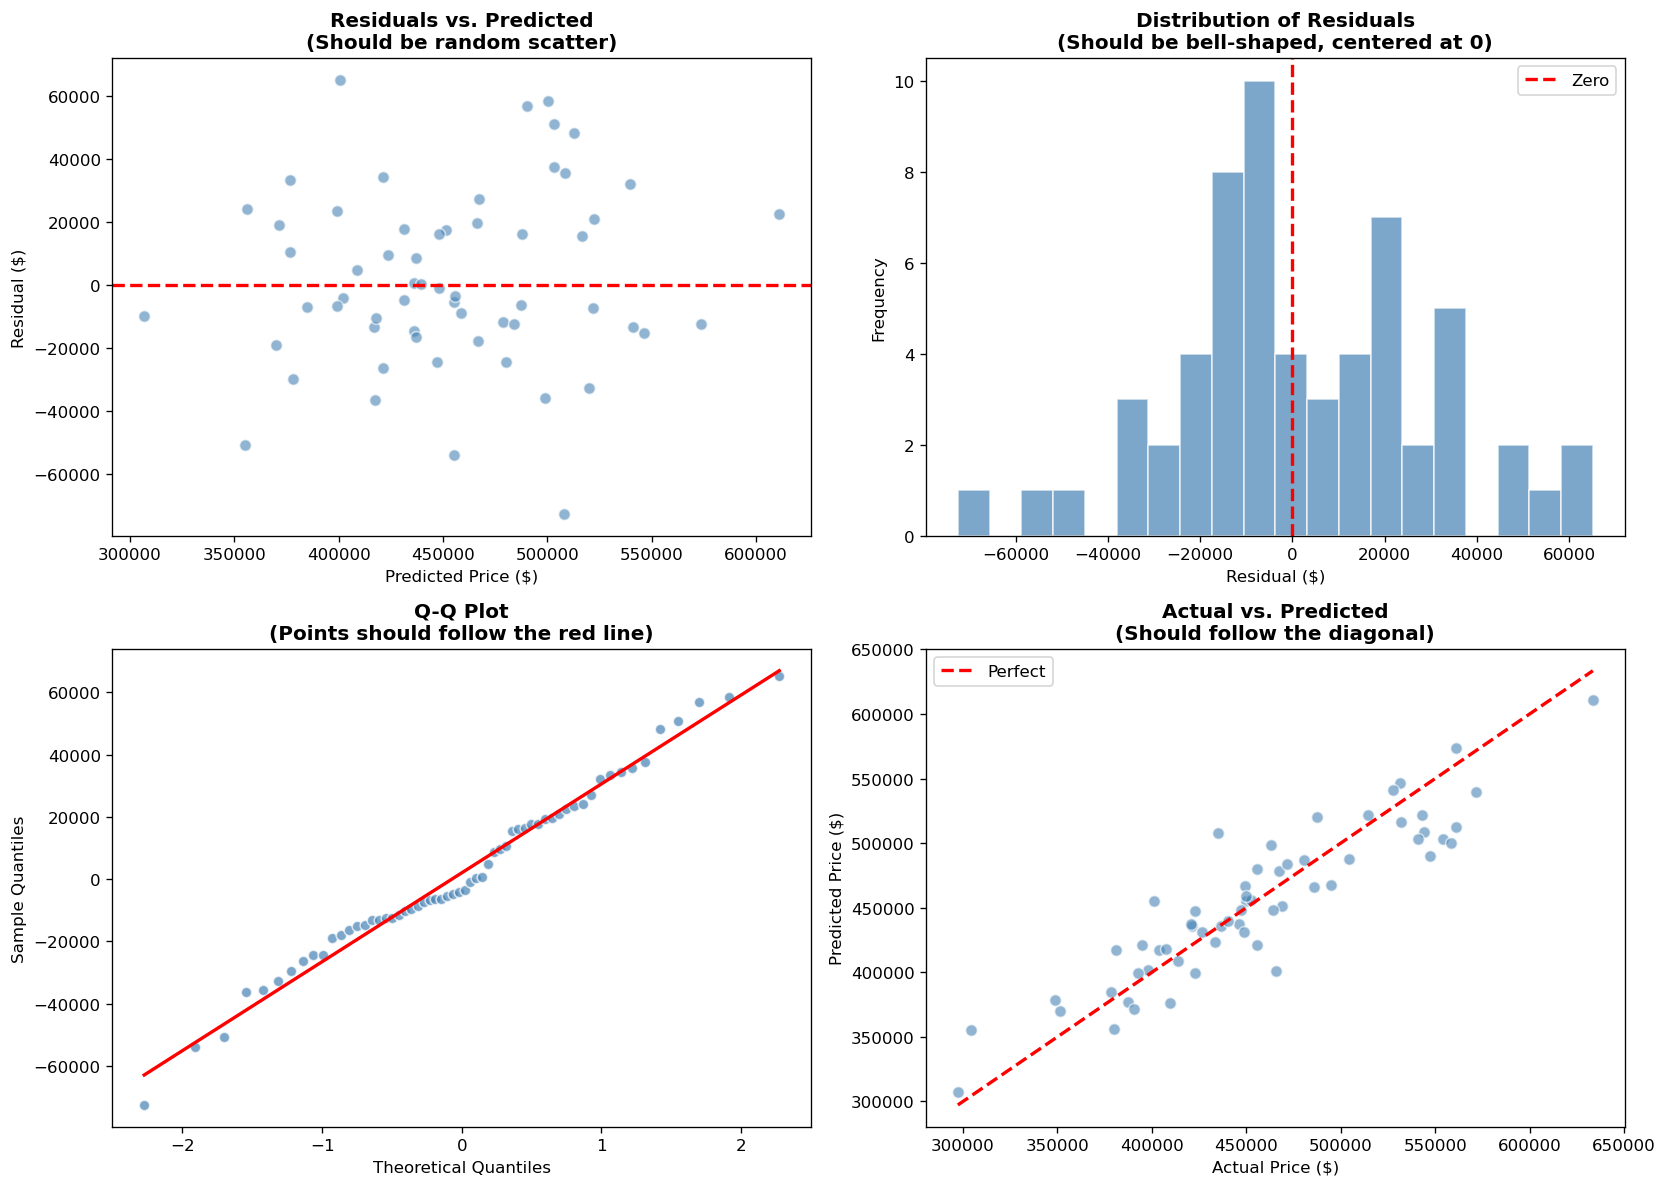

Residual statistics:
  Mean:  $2,028  (should be ≈ 0)
  Std:   $27,889
  Min:   $-72,523
  Max:   $65,113


In [25]:
# Residual analysis — checking your model
y_pred_house = full_model.predict(X_test)
residuals = y_test - y_pred_house

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted — should show no pattern
axes[0, 0].scatter(y_pred_house, residuals, color='steelblue', alpha=0.6, edgecolor='white', s=50)
axes[0, 0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0, 0].set_title('Residuals vs. Predicted\n(Should be random scatter)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Price ($)')
axes[0, 0].set_ylabel('Residual ($)')

# 2. Histogram of residuals — should look bell-shaped
axes[0, 1].hist(residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero')
axes[0, 1].set_title('Distribution of Residuals\n(Should be bell-shaped, centered at 0)',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Q-Q plot — points should follow the diagonal
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1, 0].scatter(osm, osr, color='steelblue', alpha=0.7, edgecolor='white', s=40)
axes[1, 0].plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=2)
axes[1, 0].set_title('Q-Q Plot\n(Points should follow the red line)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# 4. Actual vs Predicted — should hug the diagonal
axes[1, 1].scatter(y_test, y_pred_house, color='steelblue', alpha=0.6, edgecolor='white', s=50)
mn = min(y_test.min(), y_pred_house.min())
mx = max(y_test.max(), y_pred_house.max())
axes[1, 1].plot([mn, mx], [mn, mx], color='red', linewidth=2, linestyle='--', label='Perfect')
axes[1, 1].set_title('Actual vs. Predicted\n(Should follow the diagonal)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Actual Price ($)')
axes[1, 1].set_ylabel('Predicted Price ($)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"  Mean:  ${np.mean(residuals):,.0f}  (should be ≈ 0)")
print(f"  Std:   ${np.std(residuals):,.0f}")
print(f"  Min:   ${np.min(residuals):,.0f}")
print(f"  Max:   ${np.max(residuals):,.0f}")

### Interpreting Residual Plots

| Plot | What to Look For | Problem Indicated |
|:-----|:-----------------|:------------------|
| Residuals vs. Predicted | Random scatter around zero | A funnel shape → variance isn't constant |
| Histogram of Residuals | Symmetric bell curve centered at 0 | Skewed or multimodal → non-normal errors |
| Q-Q Plot | Points following the diagonal line | Curves at ends → heavy tails or non-normality |
| Actual vs. Predicted | Points hugging the diagonal | Wide scatter → poor overall fit |

### Pros and Cons of Linear Regression

| Advantages | Disadvantages |
|:-----------|:-------------|
| Simple to understand and explain | Assumes a straight-line relationship |
| Fast to train, even on large data | Sensitive to outliers |
| Coefficients are interpretable | Can't capture complex patterns |
| Great baseline model to start with | Assumes constant error variance |
| Widely supported in every tool | Extrapolation beyond data range is risky |

**Best practice:** Always start with linear regression as your baseline. If it's not good enough, try more complex models — but you'll always want to know what the simple model gives you first.

---

## 12.9 Business Scenarios and Common Pitfalls

### Complete Business Example: Employee Salary Prediction

A company's HR department wants to build a fair, data-driven salary model based on experience, education level, and professional certifications.

In [26]:
# Load employee salary data
employees = pd.read_csv(f"{DATA_URL}/W12/employee_salaries.csv")

print("EMPLOYEE SALARY DATA")
print("=" * 50)
print(f"Shape: {employees.shape}")
print(f"\nColumns: {list(employees.columns)}")
print(f"\nSummary statistics:")
employees.describe().round(1)

EMPLOYEE SALARY DATA
Shape: (200, 4)

Columns: ['Experience', 'Education', 'Certifications', 'Salary']

Summary statistics:


,Experience,Education,Certifications,Salary
count,200.00,200.00,200.00,200.00
mean,12.10,2.60,1.50,106805.20
std,7.40,1.10,1.20,28555.20
min,0.10,1.00,0.00,35329.00
25%,5.70,2.00,0.00,83113.50
50%,12.40,2.50,1.00,108257.50
75%,18.90,4.00,3.00,128656.00
max,24.70,4.00,3.00,167916.00


In [27]:
# Complete workflow: build a salary prediction model
features = ['Experience', 'Education', 'Certifications']
X = employees[features]
y = employees['Salary']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
salary_model = LinearRegression()
salary_model.fit(X_train, y_train)

# Evaluate
y_pred = salary_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("SALARY PREDICTION MODEL")
print("=" * 50)
print(f"\nEquation:")
print(f"  Salary = ${salary_model.intercept_:,.0f}", end="")
for feat, coef in zip(features, salary_model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} ${abs(coef):,.0f} × {feat}", end="")
print()

print(f"\nCoefficient Interpretation:")
for feat, coef in zip(features, salary_model.coef_):
    print(f"  {feat:>16}: ${coef:>8,.0f} per unit increase")

print(f"\nModel Performance:")
print(f"  R² = {r2:.3f}  (explains {r2*100:.1f}% of salary variance)")
print(f"  RMSE = ${rmse:,.0f}  (average prediction error)")

# Predict for new employees
new_employees = pd.DataFrame({
    'Experience': [2, 10, 20],
    'Education': [2, 3, 4],
    'Certifications': [0, 2, 3]
})
new_preds = salary_model.predict(new_employees)

print(f"\nSAMPLE PREDICTIONS")
print("=" * 50)
for i, (_, row) in enumerate(new_employees.iterrows()):
    print(f"  Employee {i+1}: {row['Experience']:.0f} yrs exp, "
          f"education={row['Education']:.0f}, certs={row['Certifications']:.0f} "
          f"→ ${new_preds[i]:,.0f}")

SALARY PREDICTION MODEL

Equation:
  Salary = $33,331 + $2,772 × Experience + $12,446 × Education + $5,713 × Certifications

Coefficient Interpretation:
        Experience: $   2,772 per unit increase
         Education: $  12,446 per unit increase
    Certifications: $   5,713 per unit increase

Model Performance:
  R² = 0.909  (explains 90.9% of salary variance)
  RMSE = $9,539  (average prediction error)

SAMPLE PREDICTIONS
  Employee 1: 2 yrs exp, education=2, certs=0 → $63,766
  Employee 2: 10 yrs exp, education=3, certs=2 → $109,811
  Employee 3: 20 yrs exp, education=4, certs=3 → $155,688


### When Regression Gives Bad Advice — Extrapolation

**Extrapolation** — predicting beyond the range of your training data — is one of the most dangerous mistakes in regression. The model has never seen those values and may produce wildly incorrect predictions.

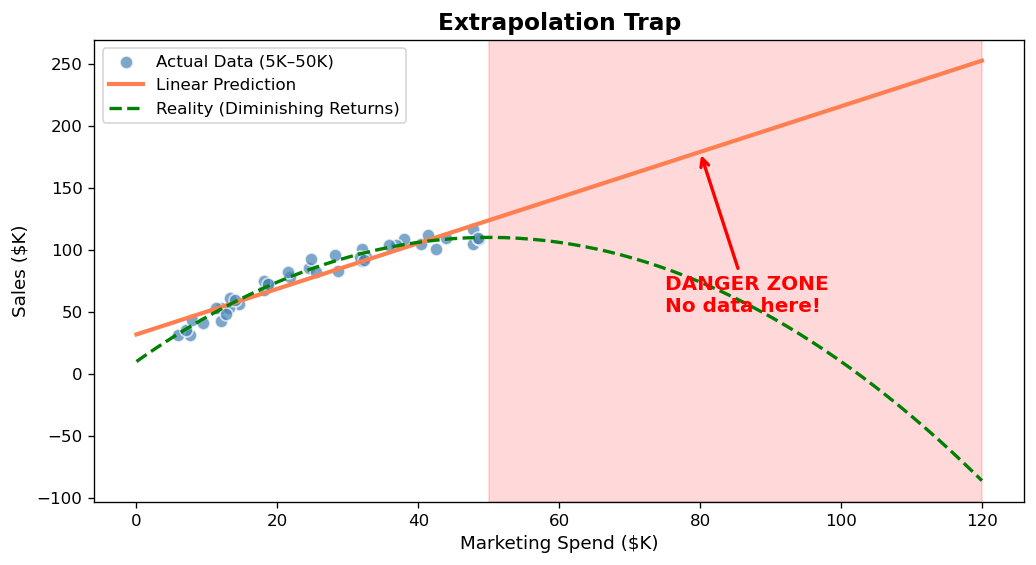

The model says: 'Spend $100K and sales will be huge!'
Reality: Returns diminish. The model was only trained on $5K–$50K.

NEVER trust predictions far outside your training data range.


In [28]:
# Extrapolation danger — the model lies beyond its training range
np.random.seed(42)
spend = np.random.uniform(5, 50, 40)
sales = 10 + 4 * spend - 0.04 * spend**2 + np.random.normal(0, 5, 40)
model_extrap = LinearRegression().fit(spend.reshape(-1, 1), sales)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(spend, sales, color='steelblue', alpha=0.7, edgecolor='white', s=60,
           label='Actual Data (5K–50K)')
extended_x = np.linspace(0, 120, 200).reshape(-1, 1)
ax.plot(extended_x, model_extrap.predict(extended_x), color='coral', linewidth=2.5,
        label='Linear Prediction')
ax.axvspan(50, 120, alpha=0.15, color='red')
ax.annotate('DANGER ZONE\nNo data here!', xy=(80, model_extrap.predict([[80]])[0]),
            xytext=(75, 50), arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, color='red', fontweight='bold')

# The real (curved) relationship
real_x = np.linspace(0, 120, 200)
ax.plot(real_x, 10 + 4*real_x - 0.04*real_x**2, color='green', linewidth=2,
        linestyle='--', label='Reality (Diminishing Returns)')

ax.set_title('Extrapolation Trap', fontsize=14, fontweight='bold')
ax.set_xlabel('Marketing Spend ($K)', fontsize=11)
ax.set_ylabel('Sales ($K)', fontsize=11)
ax.legend(fontsize=10)
plt.show()

print("The model says: 'Spend $100K and sales will be huge!'")
print("Reality: Returns diminish. The model was only trained on $5K–$50K.")
print("\nNEVER trust predictions far outside your training data range.")

### Common Mistakes

| Mistake | Problem | Fix |
|:--------|:--------|:----|
| Not splitting data | Overfitting — looks great on training data, fails on new data | Always use `train_test_split()` |
| Using 1D array for X | `ValueError: Expected 2D array` | Use `df[['col']]` not `df['col']` |
| Ignoring R² and RMSE | No idea if the model is any good | Always compute and report both |
| Extrapolating beyond data | Predictions unreliable outside training range | Only predict within the training range |
| Correlation ≠ causation | "Ad spend causes sales" vs "is associated with" | Regression finds associations, not causes |
| Too many features, too little data | Model memorizes noise | Keep features < ~10% of data points |

### Model Bias and Fairness Considerations

As you build predictive models, you must understand that **machine learning models can inherit and amplify biases** present in historical data. This is especially important for models that affect people's lives.

**What is model bias?** When a model systematically produces unfair or discriminatory results because of patterns in its training data. For example:

- A salary model trained on historical data might reflect past gender or racial pay gaps
- A hiring model might penalize candidates from certain zip codes (a proxy for race)
- A loan approval model might disadvantage applicants from certain demographic groups

**Types of Bias:**

| Type | Description | Example |
|:-----|:-----------|:--------|
| Historical | Training data reflects past discrimination | Lower salaries for women in historical records |
| Selection | Training data isn't representative | Only including data from one region or demographic |
| Proxy | Seemingly neutral features correlate with protected characteristics | Zip code → race, name → gender |

**Practical Steps for Fairer Models:**

1. **Examine your training data** for demographic imbalances
2. **Check model performance across groups** — does it predict equally well for everyone?
3. **Be cautious with proxy variables** — zip code, name, school can encode demographics
4. **Document your model's limitations** and communicate them to stakeholders
5. **Remember:** A high R² does not mean a fair model. Technical accuracy and ethical fairness are separate concerns.

**When to be extra cautious:** Hiring decisions, credit scoring, housing pricing, insurance pricing, and any model that directly affects individuals.

---

## Summary and Quick Reference

### Linear Regression Quick Reference

| Concept | Description |
|:--------|:-----------|
| **Simple Regression** | One feature predicts the target: y = β₀ + β₁x |
| **Multiple Regression** | Multiple features: y = β₀ + β₁x₁ + β₂x₂ + ... |
| **R²** | Fraction of variance explained (0 to 1, higher = better) |
| **RMSE** | Average prediction error in original units (lower = better) |
| **Intercept (β₀)** | Predicted y when all features = 0 |
| **Slope (β₁)** | Change in y for a 1-unit increase in x |
| **Residual** | Actual − Predicted (the model's error on each point) |
| **Overfitting** | Model memorizes noise; performs well on training data but poorly on test data |
| **Extrapolation** | Predicting outside the training range — unreliable and dangerous |

### scikit-learn Workflow Code

```python
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Prepare
X = df[['feature1', 'feature2']]  # double brackets!
y = df['target']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 3. Train
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluate
print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# View the equation
print(f"Intercept: {model.intercept_:.2f}")
print(f"Slopes:    {model.coef_}")
```

---

## Practice Exercises

### Exercise 1: Simple Linear Regression
Using the advertising sales data:
1. Build a simple linear regression model
2. Print the equation and interpret the coefficients
3. Calculate R² and RMSE on test data
4. Predict sales for ad budgets of $15K, $35K, and $85K

### Exercise 2: Multiple Regression
Using the house prices data:
1. Build a model using all four features
2. Compare it to a model using only Sqft
3. Which features have the largest impact? Use standardized coefficients.
4. Predict the price of a house with 2000 sqft, 3 bedrooms, 2 bathrooms, 10 years old

### Exercise 3: Residual Analysis
Using your house price model:
1. Create a residuals vs. predicted plot
2. Create a histogram of residuals
3. Do the residuals look approximately normal and centered at zero?
4. Are there any concerning patterns?

### Exercise 4: Model Comparison
Using the employee salaries data:
1. Build three models: Experience only, Education only, all features
2. Compare their R² and RMSE
3. Does adding features always improve the model?

---

## Looking Ahead: Week 13

Next week we explore **Logistic Regression** — what happens when the target is **Yes/No** instead of a number?

- Predicting probabilities of outcomes (Will the customer churn? Will the loan default?)
- Classification: turning probabilities into categories
- Confusion matrices: measuring how well the model classifies
- From linear regression to logistic regression — a natural extension

**Connection:** This week you built models that predict *how much*. Next week you'll build models that predict *which category*.